In [ ]:

#Chuẩn bị thư viện
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, welch, find_peaks

In [14]:
#Lấy danh sách record 1xx
all_records = wfdb.get_record_list('mitdb')
records_1xx = [r for r in all_records if r.startswith('1')]


Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.


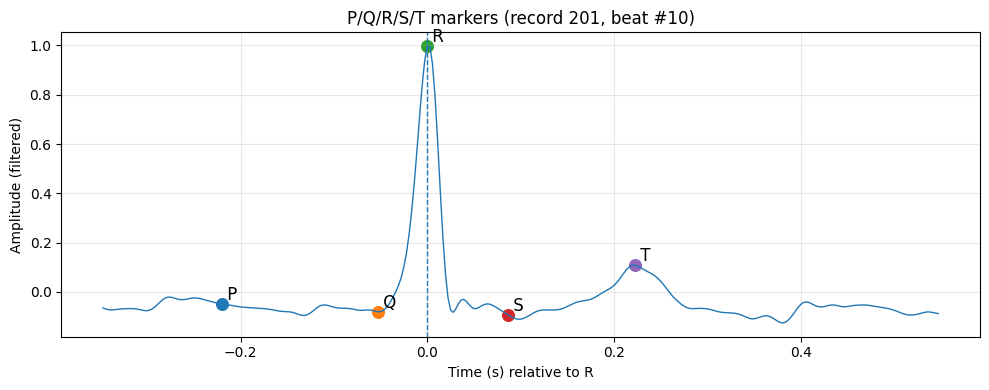

Indices: {'P': 2642, 'Q': 2702, 'R': 2721, 'S': 2752, 'T': 2801}
Rel times (s): {'P': -0.21944444444444444, 'Q': -0.05277777777777778, 'R': 0.0, 'S': 0.08611111111111111, 'T': 0.2222222222222222}


In [15]:
# Plot 1 nhịp (segment quanh R) và đánh dấu P/Q/R/S/T
# NOTE: Đây là cách "rule-based" đơn giản (hợp đồ án, dễ chạy). Không phải delineation chuẩn y khoa 100%.

import numpy as np
import matplotlib.pyplot as plt
import wfdb
import wfdb.processing as wp
from scipy.signal import butter, filtfilt

# -----------------------------
# 1) Helpers
# -----------------------------
def bandpass_filter(sig, fs, low=0.5, high=40.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, sig)

def find_local_extreme(sig, center, fs, left_s, right_s, mode="max"):
    """
    Tìm cực trị cục bộ trong cửa sổ [center - left_s, center + right_s] (tính bằng giây).
    mode: "max" hoặc "min"
    """
    L = int(left_s * fs)
    R = int(right_s * fs)
    a = max(0, center - L)
    b = min(len(sig), center + R + 1)
    window = sig[a:b]
    if len(window) == 0:
        return None
    if mode == "max":
        idx = int(np.argmax(window))
    else:
        idx = int(np.argmin(window))
    return a + idx

def delineate_pqrst_rule_based(sig, r, fs):
    """
    Rule-based delineation xấp xỉ:
    - Q: min trong [R-60ms, R-5ms]
    - S: min trong [R+5ms, R+80ms]
    - P: max trong [R-200ms, R-80ms]
    - T: max trong [R+120ms, R+400ms]
    """
    q = find_local_extreme(sig, r, fs, left_s=0.060, right_s=0.005, mode="min")
    s = find_local_extreme(sig, r, fs, left_s=0.005, right_s=0.080, mode="min")
    p = find_local_extreme(sig, r, fs, left_s=0.200, right_s=0.080, mode="max")
    t = find_local_extreme(sig, r, fs, left_s=0.120, right_s=0.400, mode="max")
    return p, q, r, s, t

# -----------------------------
# 2) Load MIT-BIH record
# -----------------------------
record_name = "201"  # đổi sang "101", "103", ...
record = wfdb.rdrecord(record_name, pn_dir="mitdb")

fs = int(record.fs)                # thường 360
ecg_raw = record.p_signal[:, 0]        # lấy channel 0 (MLII hay lead 1 tùy record)

# -----------------------------
# 3) Preprocess (bandpass) + R-peak detect
# -----------------------------
ecg = bandpass_filter(ecg_raw, fs, low=0.5, high=40.0, order=4)

r_locs = wp.xqrs_detect(sig=ecg, fs=fs)
r_locs = wp.correct_peaks(
    sig=ecg,
    peak_inds=r_locs,
    search_radius=int(0.05 * fs),        # 50 ms
    smooth_window_size=int(0.15 * fs)    # 150 ms
)

import numpy as np
import matplotlib.pyplot as plt

def find_extreme_in_range(sig, start, end, mode="max"):
    """Tìm cực trị trong [start, end) theo sample index."""
    start = max(0, start)
    end = min(len(sig), end)
    if end <= start:
        return None
    w = sig[start:end]
    idx = int(np.argmax(w)) if mode == "max" else int(np.argmin(w))
    return start + idx

def delineate_pqrst_rule_based(sig, r, fs):
    """
    Rule-based, ưu tiên để plot P/Q/R/S/T rõ:
    - Q: min trong [R-70ms, R-10ms]
    - S: min trong [R+10ms, R+90ms]
    - P: max trong [R-220ms, R-80ms]
    - T: max trong [R+120ms, R+420ms]
    """
    Q = find_extreme_in_range(sig,
                              r - int(0.070 * fs),
                              r - int(0.010 * fs),
                              mode="min")
    S = find_extreme_in_range(sig,
                              r + int(0.010 * fs),
                              r + int(0.090 * fs),
                              mode="min")
    P = find_extreme_in_range(sig,
                              r - int(0.220 * fs),
                              r - int(0.080 * fs),
                              mode="max")
    T = find_extreme_in_range(sig,
                              r + int(0.120 * fs),
                              r + int(0.420 * fs),
                              mode="max")
    return P, Q, r, S, T

# -----------------------------
# Pick 1 beat & segment rộng hơn để chứa T
# -----------------------------
beat_idx = 10 if len(r_locs) > 10 else max(0, len(r_locs)//2)
r = int(r_locs[beat_idx])

pre_s  = 0.35   # tăng lên để chứa P
post_s = 0.55   # tăng lên để chứa T (T có thể ở 300-400ms sau R)
a = max(0, r - int(pre_s * fs))
b = min(len(ecg), r + int(post_s * fs))

seg = ecg[a:b]
t = (np.arange(a, b) - r) / fs  # seconds relative to R

# -----------------------------
# Delineate P/Q/R/S/T
# -----------------------------
P, Q, R, S, T = delineate_pqrst_rule_based(ecg, r, fs)

def rel_time(idx):
    return (idx - r) / fs

points = []
if P is not None and a <= P < b: points.append(("P", rel_time(P), ecg[P]))
if Q is not None and a <= Q < b: points.append(("Q", rel_time(Q), ecg[Q]))
points.append(("R", 0.0, ecg[R]))
if S is not None and a <= S < b: points.append(("S", rel_time(S), ecg[S]))
if T is not None and a <= T < b: points.append(("T", rel_time(T), ecg[T]))

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 4))
plt.plot(t, seg, linewidth=1)
plt.axvline(0.0, linestyle="--", linewidth=1)

for name, x, y in points:
    plt.scatter([x], [y], s=70)
    plt.text(x, y, f" {name}", fontsize=12, va="bottom")

plt.title(f"P/Q/R/S/T markers (record {record_name}, beat #{beat_idx})")
plt.xlabel("Time (s) relative to R")
plt.ylabel("Amplitude (filtered)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Indices:", {"P": P, "Q": Q, "R": R, "S": S, "T": T})
print("Rel times (s):", {
    "P": None if P is None else rel_time(P),
    "Q": None if Q is None else rel_time(Q),
    "R": 0.0,
    "S": None if S is None else rel_time(S),
    "T": None if T is None else rel_time(T),
})


TIME SERIES FOR HR, RRR

In [16]:
import numpy as np
import pandas as pd

# =========================
# Build per-beat feature table (P/Q/R/S/T + RR/HR + intervals)
# =========================
def build_beat_feature_table(ecg, fs, r_locs, delineate_func):
    """
    ecg: tín hiệu đã lọc (bandpass) (1D)
    fs: sampling rate
    r_locs: sample indices R peaks (đã correct_peaks càng tốt)
    delineate_func: hàm delineate_pqrst_rule_based(sig, r, fs) -> (P,Q,R,S,T)

    Output: beat_df (DataFrame), mỗi dòng là 1 beat tại R_i (từ beat #1 trở đi vì cần RR)
    """
    r_locs = np.asarray(r_locs, dtype=int)
    if r_locs.size < 2:
        raise ValueError("Cần >= 2 R-peaks để build features (vì RR/HR cần diff).")

    def safe_amp(idx):
        if idx is None:
            return np.nan
        if idx < 0 or idx >= len(ecg):
            return np.nan
        return float(ecg[idx])

    rows = []

    # bắt đầu từ i=1 để có RR = R_i - R_{i-1}
    for i in range(1, len(r_locs)):
        R_prev = int(r_locs[i-1])
        R = int(r_locs[i])

        # RR/HR
        rr_s = (R - R_prev) / float(fs)
        hr_bpm = 60.0 / (rr_s + 1e-12)

        # delineate PQRST quanh R hiện tại
        P, Q, R0, S, T = delineate_func(ecg, R, fs)  # R0 should == R (rule-based)
        # nếu hàm trả R0 khác R thì vẫn dùng R làm chuẩn
        R0 = R

        # relative times (seconds, so với R)
        def rel_s(idx):
            return np.nan if idx is None else (idx - R0) / float(fs)

        P_rel = rel_s(P)
        Q_rel = rel_s(Q)
        S_rel = rel_s(S)
        T_rel = rel_s(T)

        # amplitudes
        P_amp = safe_amp(P)
        Q_amp = safe_amp(Q)
        R_amp = safe_amp(R0)
        S_amp = safe_amp(S)
        T_amp = safe_amp(T)

        # intervals (giây) — rule-based, có thể NaN nếu thiếu điểm
        PR_s  = np.nan if (P is None or R0 is None) else (R0 - P) / float(fs)
        QT_s  = np.nan if (Q is None or T is None) else (T - Q) / float(fs)
        QRS_s = np.nan if (Q is None or S is None) else (S - Q) / float(fs)

        # morphology “đơn giản mà hữu ích”
        PQ_amp = P_amp - Q_amp
        RS_amp = R_amp - S_amp
        ST_amp = S_amp - T_amp
        PT_amp = P_amp - T_amp

        rows.append({
            # time anchor
            "beat_i": i,
            "time_s": R0 / float(fs),

            # RR/HR
            "RR_s": rr_s,
            "HR_bpm": hr_bpm,

            # indices
            "P_idx": P, "Q_idx": Q, "R_idx": R0, "S_idx": S, "T_idx": T,

            # relative times
            "P_rel_s": P_rel, "Q_rel_s": Q_rel, "S_rel_s": S_rel, "T_rel_s": T_rel,

            # amplitudes
            "P_amp": P_amp, "Q_amp": Q_amp, "R_amp": R_amp, "S_amp": S_amp, "T_amp": T_amp,

            # intervals
            "PR_s": PR_s,
            "QT_s": QT_s,
            "QRS_s": QRS_s,

            # simple amplitude relationships
            "PQ_amp": PQ_amp,
            "RS_amp": RS_amp,
            "ST_amp": ST_amp,
            "PT_amp": PT_amp,
        })

    beat_df = pd.DataFrame(rows).set_index("time_s")
    beat_df.index.name = "time_s"
    return beat_df


beat_df = build_beat_feature_table(
    ecg=ecg,
    fs=fs,
    r_locs=r_locs,
    delineate_func=delineate_pqrst_rule_based
)

print("Per-beat feature table:")
print(beat_df.head(10))

# Nếu vẫn muốn 2 bảng RR/HR riêng như trước:
rr_df = beat_df[["RR_s"]].copy()
rr_df["RR_ms"] = rr_df["RR_s"] * 1000.0

hr_df = beat_df[["HR_bpm"]].copy()

print("\nRR time series (from beat_df):")
print(rr_df.head())

print("\nHR time series (from beat_df):")
print(hr_df.head())


Per-beat feature table:
          beat_i      RR_s      HR_bpm  P_idx  Q_idx  R_idx  S_idx  T_idx  \
time_s                                                                      
1.152778       1  0.708333   84.705882    382    398    415    425    500   
1.908333       2  0.755556   79.411765    610    667    687    697    775   
2.513889       3  0.605556   99.082569    833    883    905    936    993   
3.302778       4  0.788889   76.056338   1148   1164   1189   1200   1279   
3.952778       5  0.650000   92.307692   1390   1406   1423   1454   1507   
4.505556       6  0.552778  108.542714   1556   1603   1622   1651   1708   
5.461111       7  0.955556   62.790698   1937   1941   1966   1997   2056   
6.213889       8  0.752778   79.704797   2201   2218   2237   2246   2320   
6.933333       9  0.719444   83.397683   2449   2473   2496   2522   2577   
7.558333      10  0.625000   96.000000   2642   2702   2721   2752   2801   

           P_rel_s   Q_rel_s  ...     R_amp     S_a

In [17]:
def resample_hr_from_beat_df(beat_df, hz=1.0):
    import numpy as np
    dt = 1.0 / float(hz)
    grid = np.arange(beat_df.index.min(), beat_df.index.max() + 1e-9, dt)

    hr_resampled = (
        beat_df["HR_bpm"]
        .reindex(beat_df.index.union(grid))
        .sort_index()
        .interpolate(method="index")
        .reindex(grid)
    )
    return pd.DataFrame({"HR_bpm_resampled": hr_resampled.values}, index=pd.Index(grid, name="time_s"))

hr_1hz_df = resample_hr_from_beat_df(beat_df, hz=1.0)
print(hr_1hz_df.head())


          HR_bpm_resampled
time_s                    
1.152778         84.705882
2.152778         87.352273
3.152778         80.434565
4.152778         98.181670
5.152778         77.553703


In [32]:
import wfdb
import pandas as pd

record = "207"

ann = wfdb.rdann(record, "atr", pn_dir="mitdb")

symbols = pd.Series(ann.symbol)

print("Unique labels in record " + record + ":")
print(sorted(symbols.unique()))

print("\nCounts per label:")
print(symbols.value_counts())


Unique labels in record 207:
['!', '+', 'A', 'E', 'L', 'R', 'V', '[', ']', '|', '~']

Counts per label:
L    1457
!     472
A     107
V     105
E     105
R      86
+      24
~      15
[       6
]       6
|       2
Name: count, dtype: int64


In [41]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

def plot_available_beats(record_name="100",
                         labels=("N", "V", "A", "L", "R"),
                         window_ms=(-200, 400)):

    # Load record + annotation
    rec = wfdb.rdrecord(record_name, pn_dir="mitdb")
    ann = wfdb.rdann(record_name, "atr", pn_dir="mitdb")

    fs = rec.fs
    sig = rec.p_signal[:, 0]

    # Find which labels exist in this record
    available = sorted(set(ann.symbol))
    use_labels = [lab for lab in labels if lab in available]

    if not use_labels:
        print("No target labels found in record.")
        return

    print(f"Record {record_name} contains labels:", use_labels)

    # Window size
    left = int(window_ms[0] * fs / 1000)
    right = int(window_ms[1] * fs / 1000)

    plt.figure(figsize=(10, 6))

    for label in use_labels:

        segments = []

        for s, sym in zip(ann.sample, ann.symbol):
            if sym == label:
                if s+left >= 0 and s+right < len(sig):
                    seg = sig[s+left:s+right]
                    segments.append(seg)

        if len(segments) == 0:
            continue

        segments = np.array(segments)
        mean_wave = np.mean(segments, axis=0)

        t = np.arange(len(mean_wave)) / fs * 1000 + window_ms[0]

        plt.plot(t, mean_wave, label=f"{label} (n={len(segments)})")

    plt.axvline(0, linestyle="--")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude")
    plt.title(f"Mean beat morphology — record {record_name}")
    plt.legend()
    plt.grid(True)
    plt.show()



    t_ms = (np.arange(right - left) / fs) * 1000 + window_ms[0]

    for label in use_labels:
        segments = []

        for s, sym in zip(ann.sample, ann.symbol):
            if sym == label:
                a = s + left
                b = s + right
                if a >= 0 and b <= len(sig):
                    segments.append(sig[a:b])

        if len(segments) == 0:
            continue

        segments = np.array(segments, dtype=np.float64)
        mean_wave = segments.mean(axis=0)

        # --- Plot riêng từng label ---
        plt.figure(figsize=(10, 4))
        plt.plot(t_ms, mean_wave, linewidth=2, label=f"{label} (n={len(segments)})")
        plt.axvline(0, linestyle="--", linewidth=1)
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude")
        plt.title(f"Mean beat morphology — record {record_name} | label {label}")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()



Record 100 contains labels: ['N', 'V', 'A']


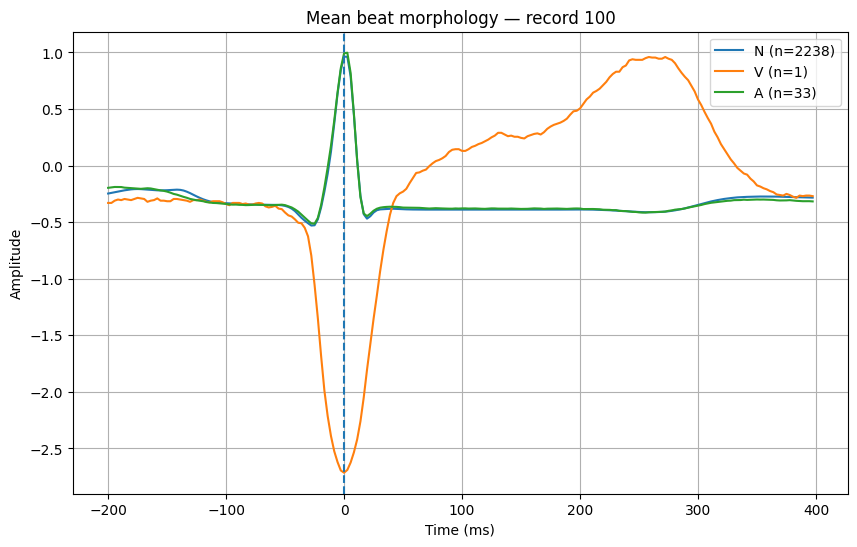

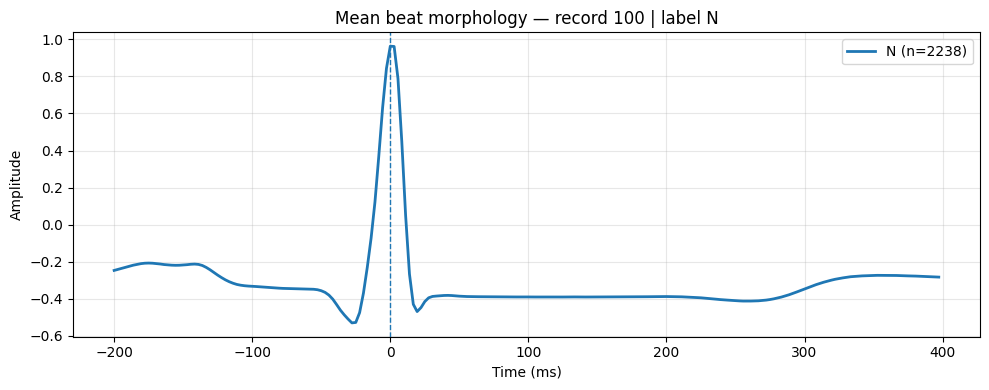

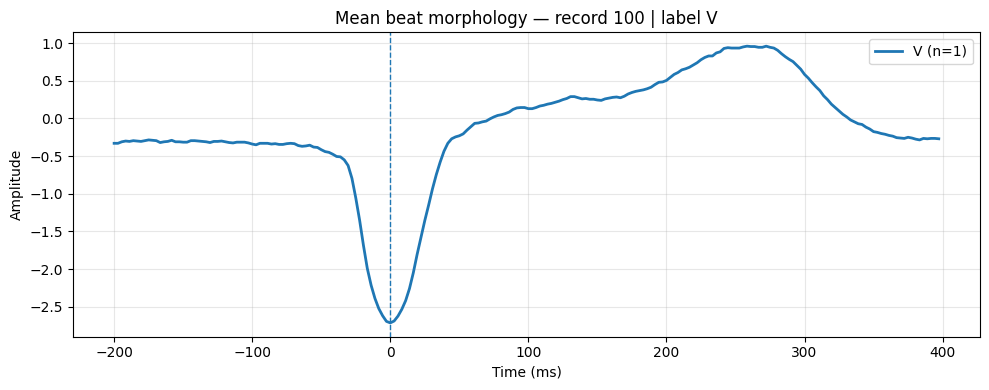

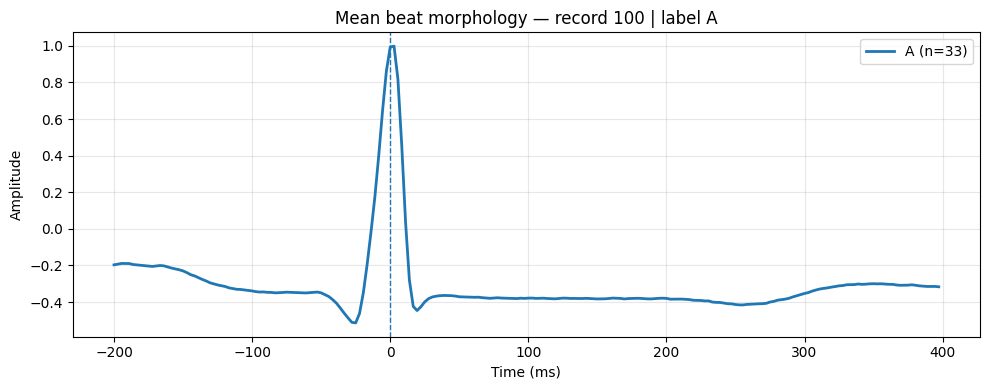

Record 203 contains labels: ['N', 'V']


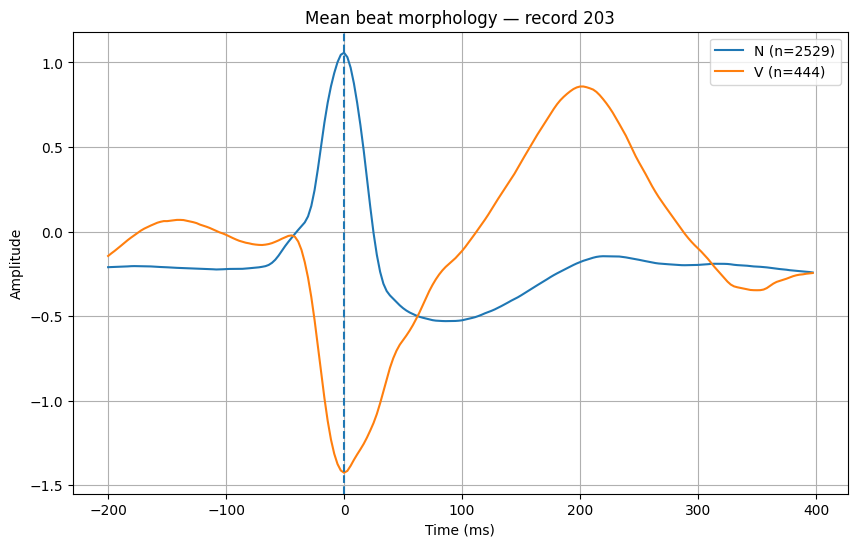

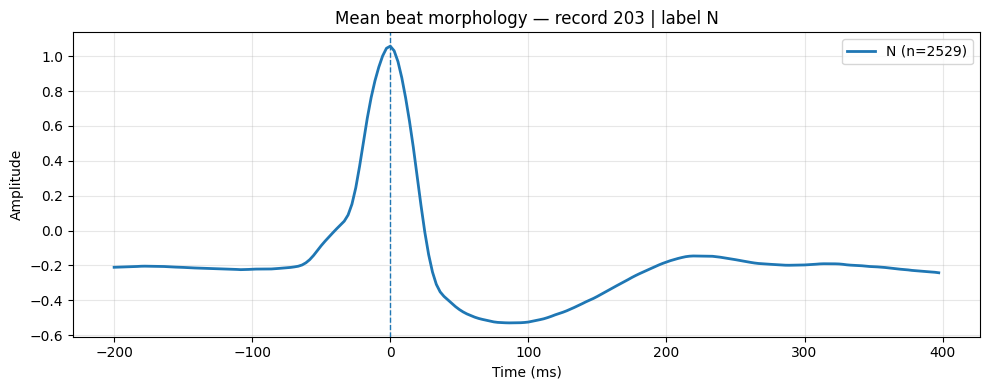

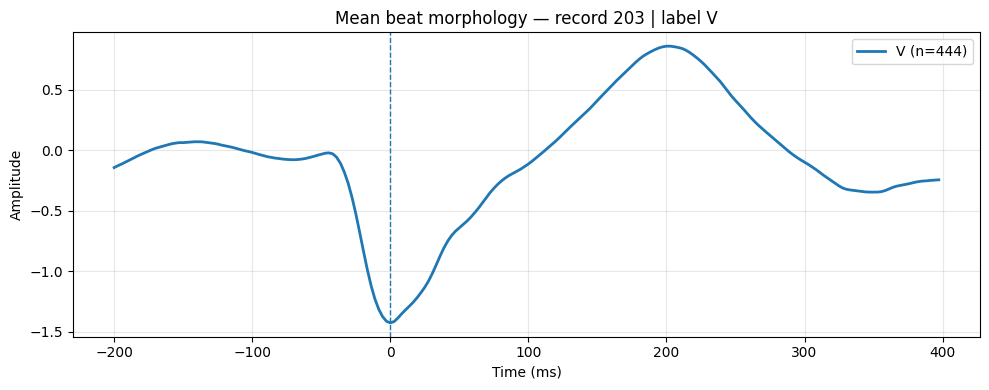

Record 111 contains labels: ['V', 'L']


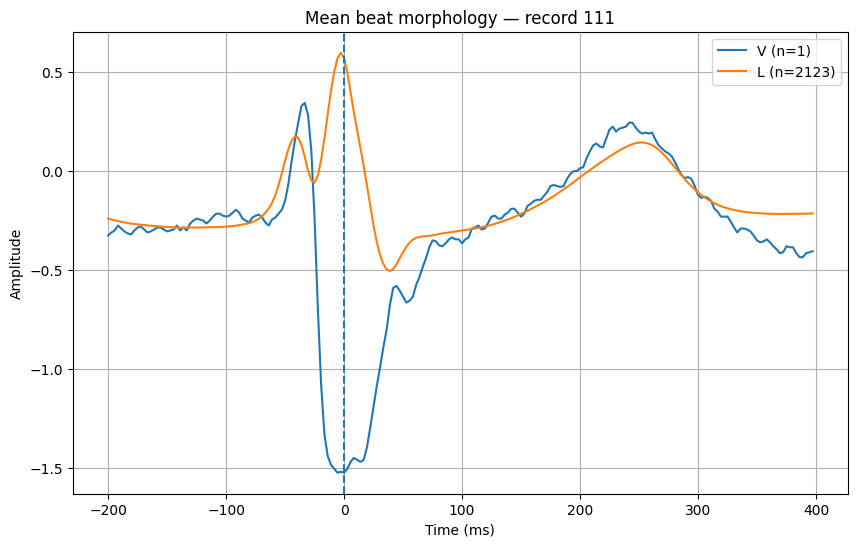

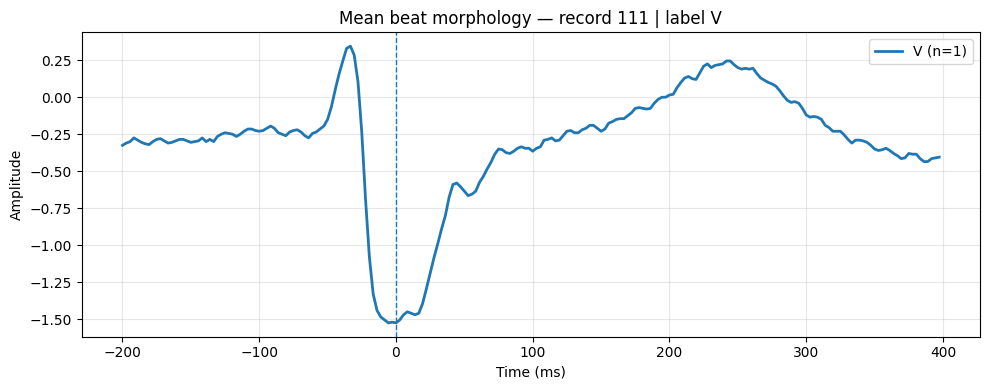

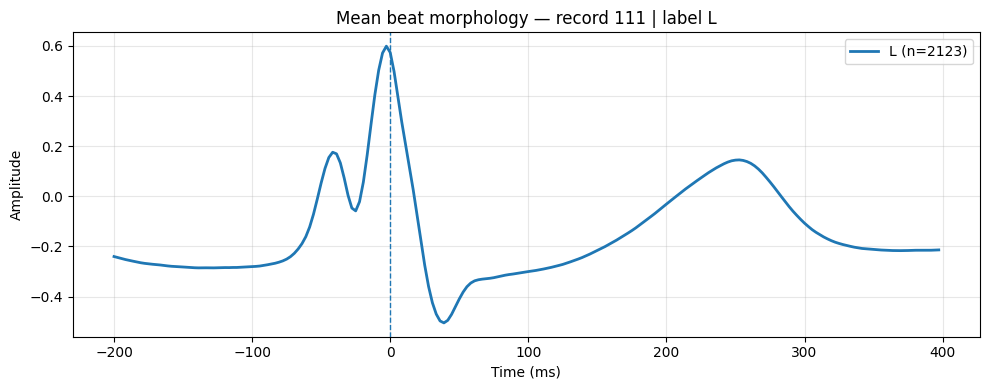

Record 207 contains labels: ['V', 'A', 'L', 'R']


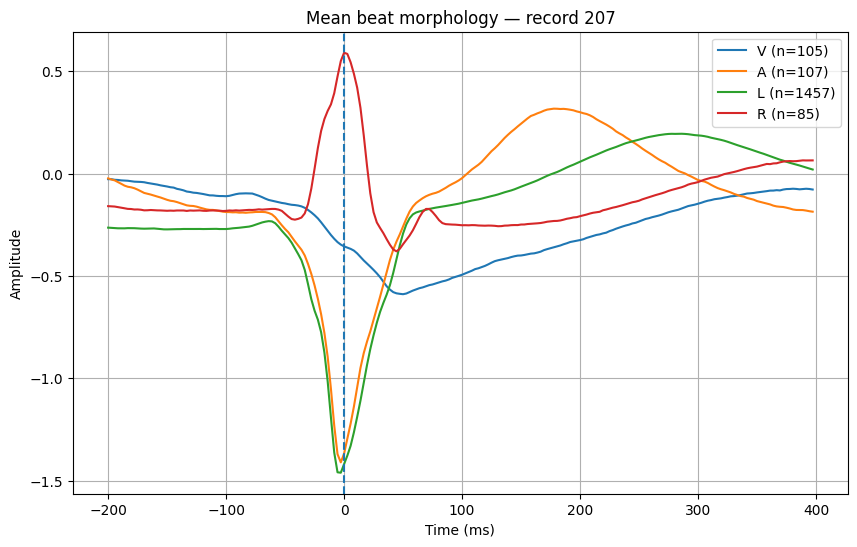

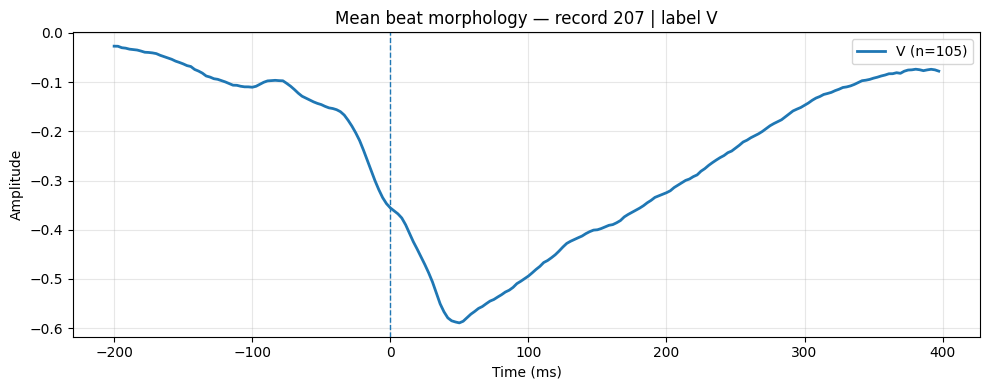

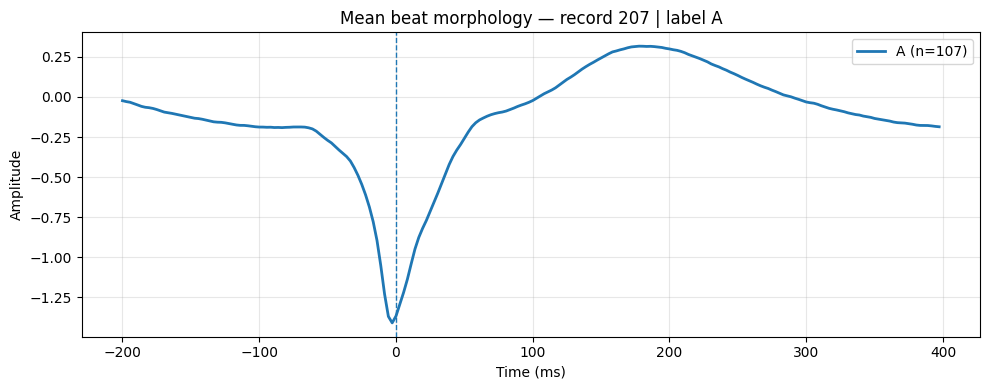

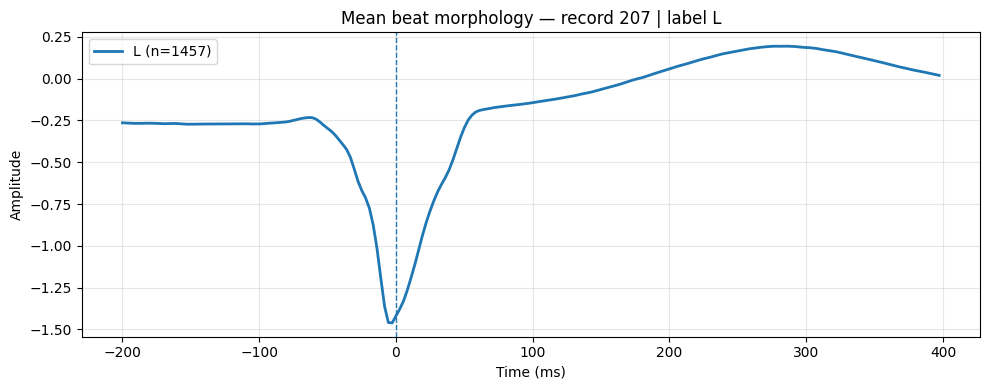

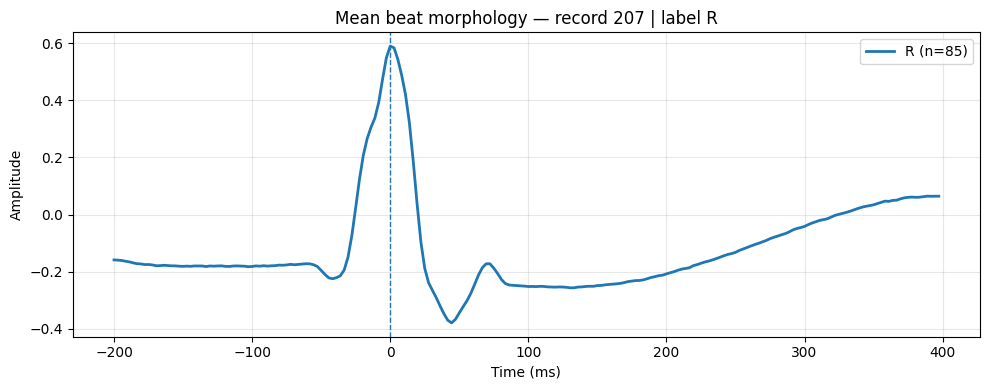

In [42]:
plot_available_beats("100")
plot_available_beats("203")
plot_available_beats("111")
plot_available_beats("207")



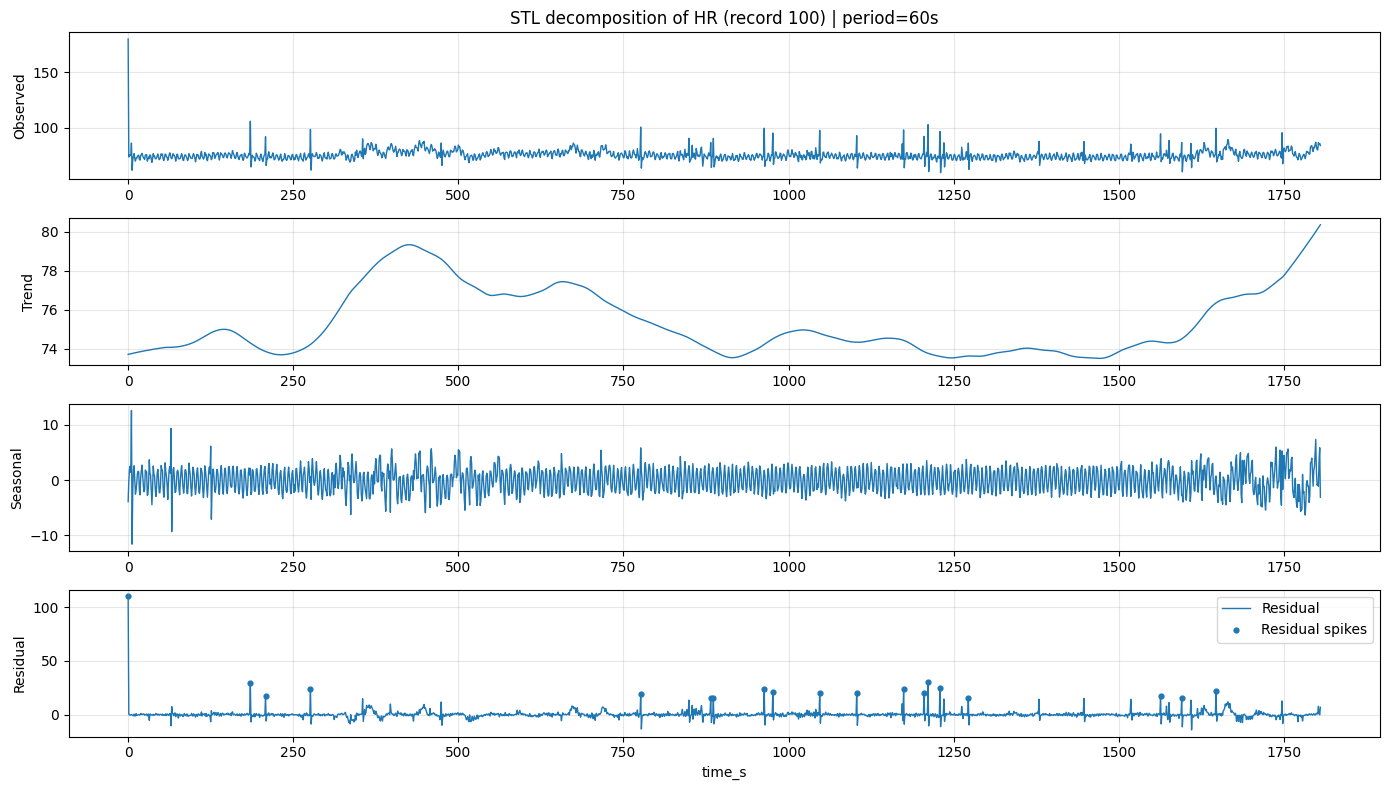

{'record': '100', 'fs': 360.0, 'n_beats': 2274, 'duration_s': 1805.4805555555556, 'resample_hz': 1.0, 'stl_period_seconds': 60.0, 'stl_period_samples': 60, 'abnormal_residual_points': 19, 'spike_rule': {'method': 'percentile', 'p': 99, 'thr_abs': 15.169908968321844}}
          HR_bpm_resampled
time_s                    
0.131944        180.000000
1.131944         73.878953
2.131944         75.792254
3.131944         75.826056
4.131944         75.031404
            observed      trend  seasonal       resid
time_s                                               
0.131944  180.000000  73.722059 -3.902134  110.180076
1.131944   73.878953  73.730251 -0.227511    0.376213
2.131944   75.792254  73.738378  1.973517    0.080359
3.131944   75.826056  73.746436  2.506799   -0.427178
4.131944   75.031404  73.754423  1.408876   -0.131895


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from statsmodels.tsa.seasonal import STL

def ecg_hr_pipeline_with_annotations(
    record_name="100",
    pn_dir="mitdb",
    annotator="atr",
    resample_hz=1.0,
    hr_clip=(30, 180),
    stl_period=60,          # thử 30/60/120
    stl_robust=True,
    spike_method="percentile",  # "percentile" hoặc "robust_z"
    spike_p=99,
    spike_z=3.5,
    plot=True
):
    """
    End-to-end:
      1) Read MIT-BIH annotation beats (ground truth)
      2) Build RR + HR beat-to-beat
      3) Resample HR to regular grid (e.g., 1 Hz)
      4) STL decomposition (trend/seasonal/resid)
      5) Flag abnormal residual spikes

    Returns:
      rr_df, hr_b2b_df, hr_resampled_df, decomp_df, flags, summary
    """

    # ---------- 1) Load record + annotations ----------
    rec = wfdb.rdrecord(record_name, pn_dir=pn_dir)
    fs = float(rec.fs)

    ann = wfdb.rdann(record_name, annotator, pn_dir=pn_dir)
    r_samples = np.asarray(ann.sample, dtype=int)
    if r_samples.size < 2:
        raise RuntimeError("Not enough annotated beats to compute RR/HR.")

    r_times = r_samples / fs  # seconds

    # ---------- 2) RR series ----------
    rr_s = np.diff(r_times)
    rr_time = r_times[1:]
    rr_df = pd.DataFrame(
        {"RR_s": rr_s, "RR_ms": rr_s * 1000.0},
        index=pd.Index(rr_time, name="time_s")
    )

    # ---------- 3) HR beat-to-beat ----------
    hr_bpm = 60.0 / (rr_s + 1e-12)
    hr_time = (r_times[:-1] + r_times[1:]) / 2.0
    hr_b2b_df = pd.DataFrame(
        {"HR_bpm": hr_bpm},
        index=pd.Index(hr_time, name="time_s")
    )

    # ---------- 4) Resample HR to regular grid ----------
    if resample_hz is None or resample_hz <= 0:
        raise ValueError("resample_hz must be > 0 for STL decomposition.")

    dt = 1.0 / float(resample_hz)
    grid = np.arange(hr_b2b_df.index.min(), hr_b2b_df.index.max() + 1e-9, dt)

    hr_resampled = (
        hr_b2b_df["HR_bpm"]
        .reindex(hr_b2b_df.index.union(grid))
        .sort_index()
        .interpolate(method="index")
        .reindex(grid)
    )

    if hr_clip is not None:
        lo, hi = hr_clip
        hr_resampled = hr_resampled.clip(lo, hi)

    hr_resampled_df = pd.DataFrame(
        {"HR_bpm_resampled": hr_resampled.values},
        index=pd.Index(grid, name="time_s")
    )

    # ---------- 5) STL decomposition ----------
    hr_series = hr_resampled_df["HR_bpm_resampled"].astype(float)
    stl = STL(hr_series, period=int(stl_period * resample_hz), robust=stl_robust)
    res = stl.fit()

    decomp_df = pd.DataFrame({
        "observed": hr_series.values,
        "trend": res.trend,
        "seasonal": res.seasonal,
        "resid": res.resid
    }, index=hr_resampled_df.index)
    decomp_df.index.name = "time_s"

    # ---------- 6) Flag residual spikes ----------
    resid = decomp_df["resid"].astype(float)

    if spike_method == "percentile":
        thr = np.nanpercentile(np.abs(resid.values), spike_p)
        flags = np.abs(resid) > thr
        spike_info = {"method": "percentile", "p": spike_p, "thr_abs": float(thr)}
    elif spike_method == "robust_z":
        med = np.nanmedian(resid.values)
        mad = np.nanmedian(np.abs(resid.values - med)) + 1e-12
        rz = 0.6745 * (resid - med) / mad
        flags = np.abs(rz) > spike_z
        spike_info = {"method": "robust_z", "z": spike_z, "median": float(med), "mad": float(mad)}
    else:
        raise ValueError("spike_method must be 'percentile' or 'robust_z'")

    summary = {
        "record": record_name,
        "fs": fs,
        "n_beats": int(len(r_times)),
        "duration_s": float(r_times.max() - r_times.min()),
        "resample_hz": float(resample_hz),
        "stl_period_seconds": float(stl_period),
        "stl_period_samples": int(stl_period * resample_hz),
        "abnormal_residual_points": int(flags.sum()),
        "spike_rule": spike_info,
    }

    # ---------- 7) Plots ----------
    if plot:
        t = decomp_df.index.values

        plt.figure(figsize=(14, 8))

        ax1 = plt.subplot(4, 1, 1)
        ax1.plot(t, decomp_df["observed"], linewidth=1)
        ax1.set_title(f"STL decomposition of HR (record {record_name}) | period={stl_period}s")
        ax1.set_ylabel("Observed")

        ax2 = plt.subplot(4, 1, 2, sharex=ax1)
        ax2.plot(t, decomp_df["trend"], linewidth=1)
        ax2.set_ylabel("Trend")

        ax3 = plt.subplot(4, 1, 3, sharex=ax1)
        ax3.plot(t, decomp_df["seasonal"], linewidth=1)
        ax3.set_ylabel("Seasonal")

        ax4 = plt.subplot(4, 1, 4, sharex=ax1)
        ax4.plot(t, decomp_df["resid"], linewidth=1, label="Residual")
        if flags.any():
            ax4.scatter(t[flags.values], decomp_df["resid"][flags].values, s=12, label="Residual spikes")
        ax4.set_ylabel("Residual")
        ax4.set_xlabel("time_s")
        ax4.legend()

        for ax in [ax1, ax2, ax3, ax4]:
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return rr_df, hr_b2b_df, hr_resampled_df, decomp_df, flags, summary


# =========================
# Example
# =========================
if __name__ == "__main__":
    rr_df, hr_b2b_df, hr_1hz_df, decomp_df, flags, summary = ecg_hr_pipeline_with_annotations(
        record_name="100",
        resample_hz=1.0,
        stl_period=60,
        spike_method="percentile",
        spike_p=99,
        plot=True
    )
    print(summary)
    print(hr_1hz_df.head())
    print(decomp_df.head())


Loading data...
Filtering...
Detecting R-peaks...
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Building RR & HR...
Resampling HR...
Computing HRV...
Detecting abnormalities...
Running STL...
Plotting...


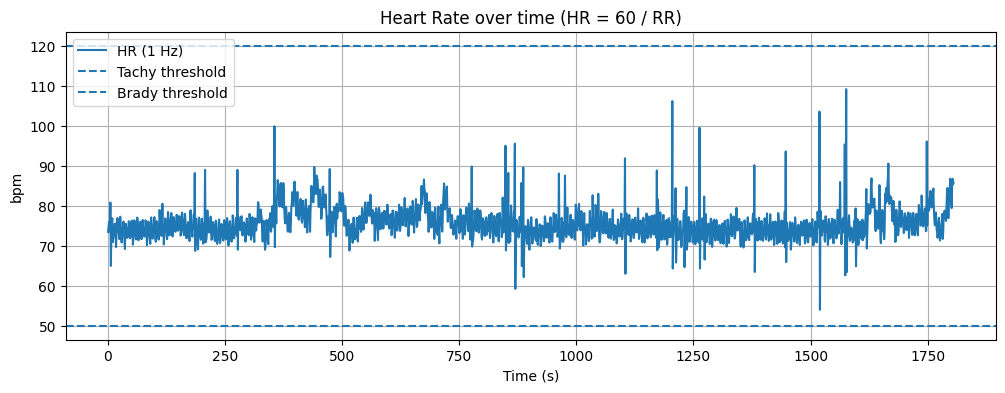

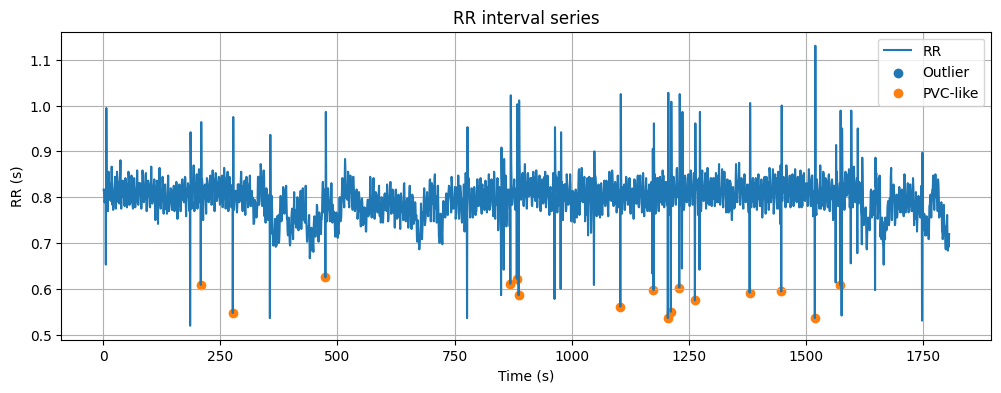

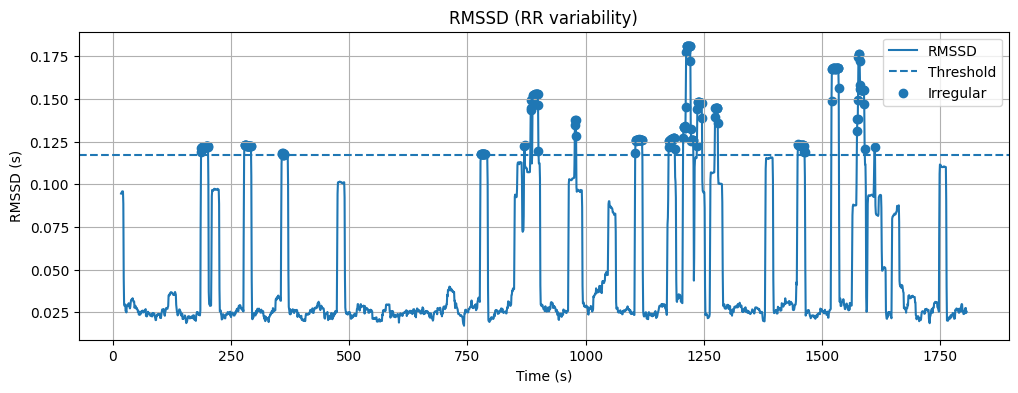

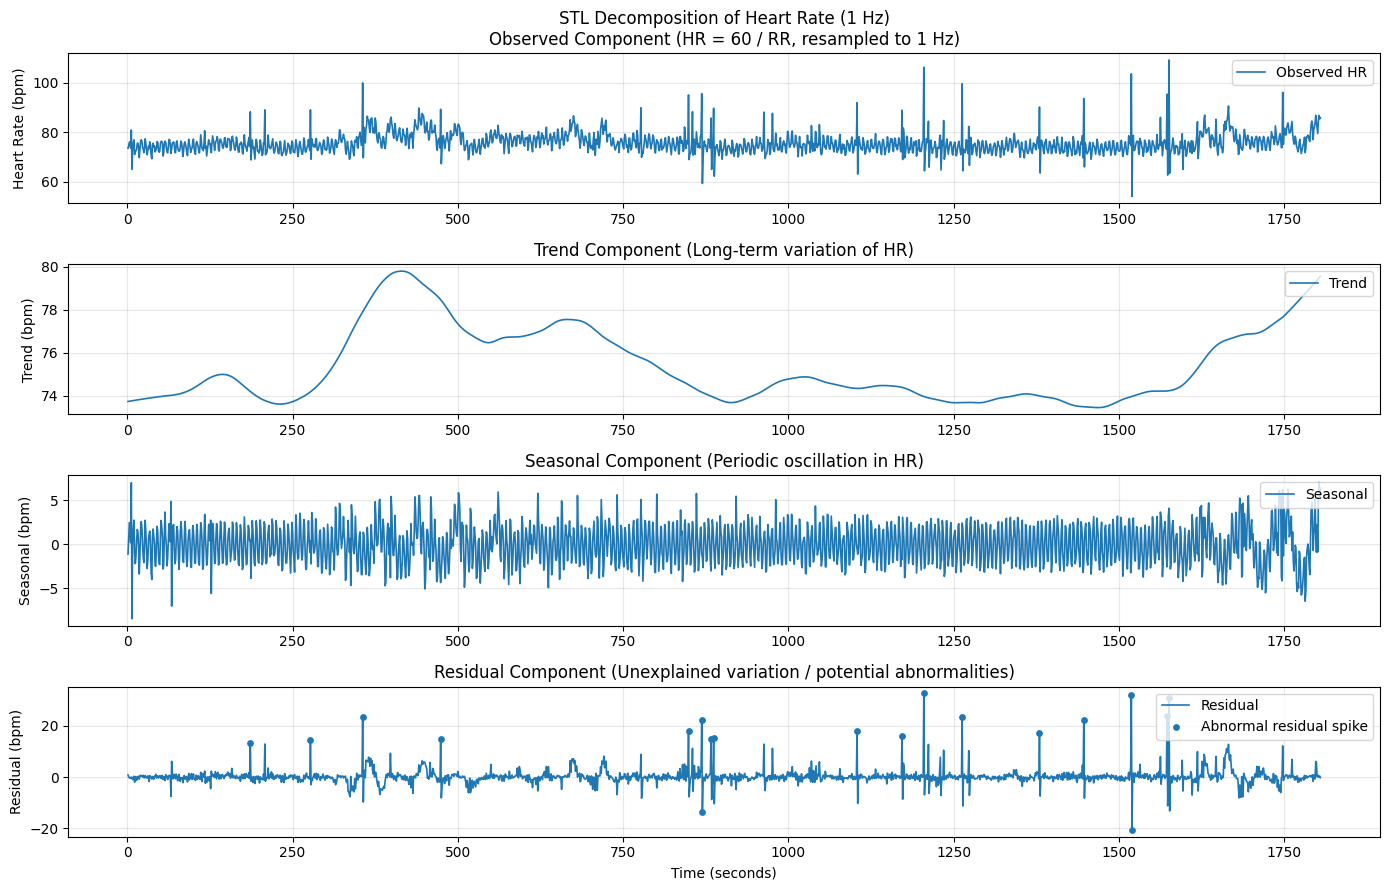

Done!


In [15]:
# =========================================================
# MAIN ECG TIME SERIES PIPELINE
# =========================================================

import numpy as np
import pandas as pd
import wfdb
import wfdb.processing as wp
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL


# =========================================================
# 1) FILTER
# =========================================================
def bandpass_filter(sig, fs, low=0.5, high=40.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, sig)


# =========================================================
# 2) BUILD RR & HR
# =========================================================
def build_rr_hr( r_locs, fs):
    r_times = r_locs / fs
    rr = np.diff(r_times)
    hr = 60.0 / (rr + 1e-12)

    beat_time = r_times[1:]

    beat_df = pd.DataFrame({
        "RR_s": rr,
        "HR_bpm": hr
    }, index=beat_time)

    beat_df.index.name = "time_s"
    return beat_df


# =========================================================
# 3) RESAMPLE HR
# =========================================================
def resample_hr(beat_df, hz=1.0):
    dt = 1.0 / hz
    grid = np.arange(beat_df.index.min(), beat_df.index.max(), dt)

    hr_resampled = (
        beat_df["HR_bpm"]
        .reindex(beat_df.index.union(grid))
        .sort_index()
        .interpolate(method="index")
        .reindex(grid)
    )

    return pd.DataFrame({"HR_bpm_resampled": hr_resampled.values},
                        index=pd.Index(grid, name="time_s"))


# =========================================================
# 4) HRV METRICS
# =========================================================
def compute_hrv(beat_df, win=20):
    rr = beat_df["RR_s"]

    beat_df["RMSSD_s"] = np.sqrt(
        rr.diff().pow(2).rolling(win).mean()
    )

    beat_df["SDNN_s"] = rr.rolling(win).std()

    return beat_df


# =========================================================
# 5) RULE-BASED DETECTION
# =========================================================
def detect_abnormal(beat_df, hr_df):
    med_rr = beat_df["RR_s"].median()

    # RR outliers
    beat_df["RR_outlier"] = (
        (beat_df["RR_s"] < 0.5 * med_rr) |
        (beat_df["RR_s"] > 1.8 * med_rr)
    )

    # irregular (RMSSD threshold)
    thr = np.nanpercentile(beat_df["RMSSD_s"], 90)
    beat_df["irregular"] = beat_df["RMSSD_s"] > thr

    # PVC-like
    rr = beat_df["RR_s"].values
    pvc = np.zeros(len(rr), dtype=bool)
    for i in range(len(rr)-1):
        if rr[i] < 0.8*med_rr and rr[i+1] > 1.2*med_rr:
            pvc[i] = True
    beat_df["pvc_like"] = pvc

    # HR episodes
    hr_df["tachy"] = hr_df["HR_bpm_resampled"] > 120
    hr_df["brady"] = hr_df["HR_bpm_resampled"] < 50

    return beat_df, hr_df, thr


# =========================================================
# 6) STL
# =========================================================
def run_stl(hr_df):
    hr = hr_df["HR_bpm_resampled"].interpolate()
    stl = STL(hr, period=60, robust=True)
    res = stl.fit()

    return pd.DataFrame({
        "observed": hr,
        "trend": res.trend,
        "seasonal": res.seasonal,
        "resid": res.resid
    })


# =========================================================
# 7) PLOT
# =========================================================
def plot_all(beat_df, hr_df, decomp_df, rmssd_thr):

    # HR
    plt.figure(figsize=(12,4))
    plt.plot(hr_df.index, hr_df["HR_bpm_resampled"], label="HR (1 Hz)")
    plt.axhline(120, linestyle="--", label="Tachy threshold")
    plt.axhline(50, linestyle="--", label="Brady threshold")
    plt.title("Heart Rate over time (HR = 60 / RR)")
    plt.xlabel("Time (s)")
    plt.ylabel("bpm")
    plt.legend()
    plt.grid()
    plt.show()

    # RR
    plt.figure(figsize=(12,4))
    plt.plot(beat_df.index, beat_df["RR_s"], label="RR")
    plt.scatter(beat_df.index[beat_df["RR_outlier"]],
                beat_df["RR_s"][beat_df["RR_outlier"]],
                label="Outlier")
    plt.scatter(beat_df.index[beat_df["pvc_like"]],
                beat_df["RR_s"][beat_df["pvc_like"]],
                label="PVC-like")
    plt.title("RR interval series")
    plt.xlabel("Time (s)")
    plt.ylabel("RR (s)")
    plt.legend()
    plt.grid()
    plt.show()

    # RMSSD
    plt.figure(figsize=(12,4))
    plt.plot(beat_df.index, beat_df["RMSSD_s"], label="RMSSD")
    plt.axhline(rmssd_thr, linestyle="--", label="Threshold")
    plt.scatter(beat_df.index[beat_df["irregular"]],
                beat_df["RMSSD_s"][beat_df["irregular"]],
                label="Irregular")
    plt.title("RMSSD (RR variability)")
    plt.xlabel("Time (s)")
    plt.ylabel("RMSSD (s)")
    plt.legend()
    plt.grid()
    plt.show()

    # STL
def plot_stl_fixed(decomp_df, flags=None):

    t = decomp_df.index.values

    fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)

    # =========================
    # 1) OBSERVED
    # =========================
    axes[0].plot(t, decomp_df["observed"], linewidth=1.2, label="Observed HR")
    axes[0].set_title(
        "STL Decomposition of Heart Rate (1 Hz)\n"
        "Observed Component (HR = 60 / RR, resampled to 1 Hz)"
    )
    axes[0].set_ylabel("Heart Rate (bpm)")
    axes[0].legend(loc="upper right")
    axes[0].grid(True, alpha=0.3)

    # =========================
    # 2) TREND
    # =========================
    axes[1].plot(t, decomp_df["trend"], linewidth=1.2, label="Trend")
    axes[1].set_title("Trend Component (Long-term variation of HR)")
    axes[1].set_ylabel("Trend (bpm)")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)

    # =========================
    # 3) SEASONAL
    # =========================
    axes[2].plot(t, decomp_df["seasonal"], linewidth=1.2, label="Seasonal")
    axes[2].set_title("Seasonal Component (Periodic oscillation in HR)")
    axes[2].set_ylabel("Seasonal (bpm)")
    axes[2].legend(loc="upper right")
    axes[2].grid(True, alpha=0.3)

    # =========================
    # 4) RESIDUAL
    # =========================
    axes[3].plot(t, decomp_df["resid"], linewidth=1.2, label="Residual")

    if flags is not None and np.any(flags):
        axes[3].scatter(
            t[flags],
            decomp_df["resid"][flags],
            s=15,
            label="Abnormal residual spike"
        )

    axes[3].set_title(
        "Residual Component (Unexplained variation / potential abnormalities)"
    )
    axes[3].set_xlabel("Time (seconds)")
    axes[3].set_ylabel("Residual (bpm)")
    axes[3].legend(loc="upper right")
    axes[3].grid(True, alpha=0.3)

    # =========================
    # FIX QUAN TRỌNG: HIỂN THỊ TICKS
    # =========================
    for ax in axes:
        ax.tick_params(axis='both', labelsize=10)  # đảm bảo hiện số
        ax.yaxis.set_tick_params(labelleft=True)
        ax.xaxis.set_tick_params(labelbottom=True)

    # đảm bảo trục X có số ở tất cả subplot
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    plt.tight_layout()
    plt.show()


# =========================================================
# ======================= MAIN =============================
# =========================================================
def main():

    record_name = "100"

    print("Loading data...")
    record = wfdb.rdrecord(record_name, pn_dir="mitdb")

    fs = record.fs
    ecg = record.p_signal[:, 0]

    print("Filtering...")
    ecg = bandpass_filter(ecg, fs)

    print("Detecting R-peaks...")
    r_locs = wp.xqrs_detect(sig=ecg, fs=fs)

    print("Building RR & HR...")
    beat_df = build_rr_hr(r_locs, fs)

    print("Resampling HR...")
    hr_df = resample_hr(beat_df)

    print("Computing HRV...")
    beat_df = compute_hrv(beat_df)

    print("Detecting abnormalities...")
    beat_df, hr_df, rmssd_thr = detect_abnormal(beat_df, hr_df)

    print("Running STL...")
    decomp_df = run_stl(hr_df)
    flags = np.abs(decomp_df["resid"]) > np.percentile(np.abs(decomp_df["resid"]), 99)
    
    print("Plotting...")
    plot_all(beat_df, hr_df, decomp_df, rmssd_thr)

    plot_stl_fixed(decomp_df, flags)
    print("Done!")


# =========================================================
if __name__ == "__main__":
    main()

Number of beats: 1887
Beat length (samples): 288


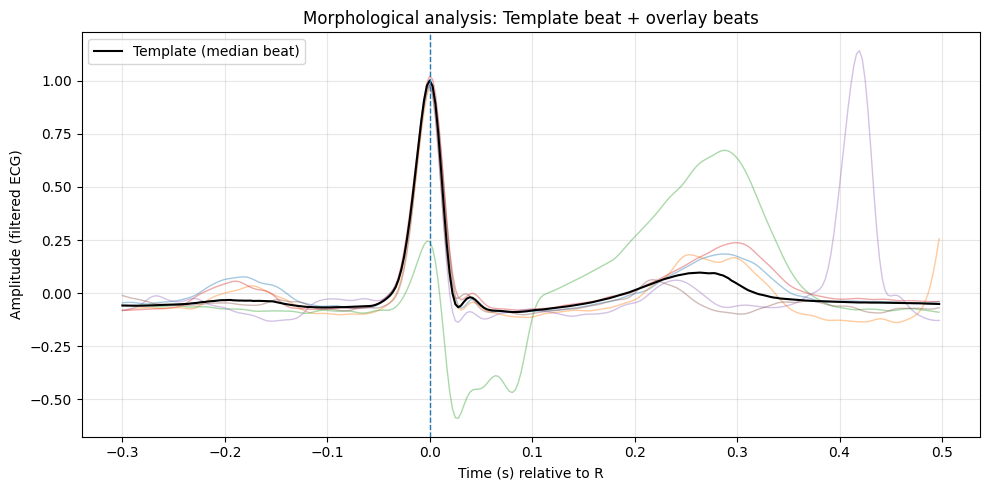

Correlation stats:
  min: 0.2376955530069084
  mean: 0.87088828585434
  max: 0.9964387347926653


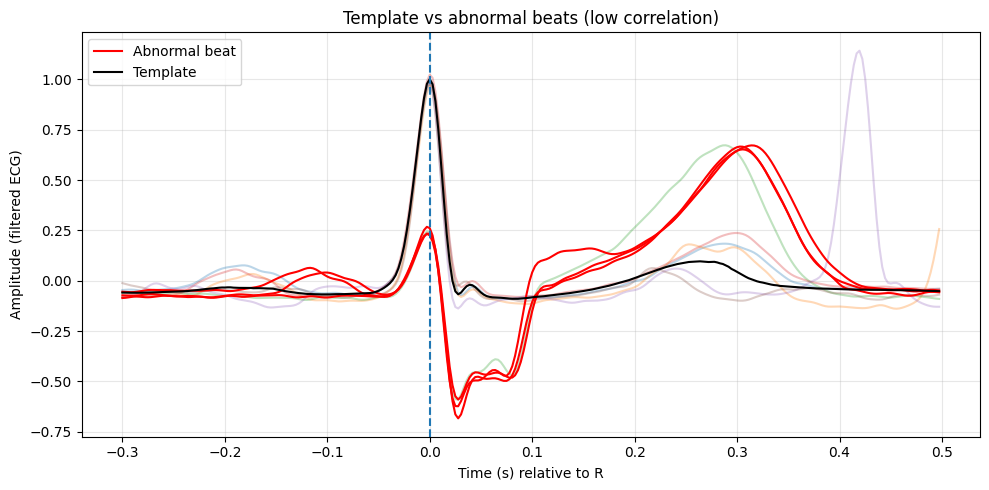

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 4.5 MORPHOLOGICAL FEATURES – TEMPLATE + OVERLAY BEATS
# =========================================================

# -----------------------------
# 1. Parameters: cửa sổ cắt beat quanh R
# -----------------------------
pre_s  = 0.30   # 300 ms trước R (đủ chứa P)
post_s = 0.50   # 500 ms sau R (đủ chứa T)

pre_n  = int(pre_s * fs)
post_n = int(post_s * fs)
beat_len = pre_n + post_n

# -----------------------------
# 2. Cắt tất cả beats
# -----------------------------
beats = []
valid_r = []

for r in r_locs:
    r = int(r)
    if r - pre_n < 0 or r + post_n >= len(ecg):
        continue
    beats.append(ecg[r - pre_n : r + post_n])
    valid_r.append(r)

beats = np.array(beats)   # shape: (num_beats, beat_len)
print("Number of beats:", beats.shape[0])
print("Beat length (samples):", beats.shape[1])

# Time axis (R tại 0s)
t = (np.arange(beat_len) - pre_n) / fs

# -----------------------------
# 3. Template beat (median beat)
# -----------------------------
template = np.median(beats, axis=0)

# -----------------------------
# 4. Overlay vài beats để xem biến dạng
# -----------------------------
np.random.seed(0)
num_overlay = min(6, len(beats))
overlay_idx = np.random.choice(len(beats), num_overlay, replace=False)
overlay_beats = beats[overlay_idx]

plt.figure(figsize=(10, 5))

# Overlay beats (mờ)
for b in overlay_beats:
    plt.plot(t, b, alpha=0.4, linewidth=1)

# Template beat (đậm)
plt.plot(t, template, color="black", linewidth=1.5, label="Template (median beat)")

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Morphological analysis: Template beat + overlay beats")
plt.xlabel("Time (s) relative to R")
plt.ylabel("Amplitude (filtered ECG)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 5. Correlation với template (để phát hiện beat biến dạng)
# -----------------------------
def corr_with_template(x, m):
    x0 = x - np.mean(x)
    m0 = m - np.mean(m)
    return np.dot(x0, m0) / (np.linalg.norm(x0) * np.linalg.norm(m0))

corrs = np.array([corr_with_template(b, template) for b in beats])

print("Correlation stats:")
print("  min:", np.min(corrs))
print("  mean:", np.mean(corrs))
print("  max:", np.max(corrs))

# -----------------------------
# 6. Plot template + beat bất thường (corr thấp)
# -----------------------------
num_abnormal = min(3, len(beats))
abnormal_idx = np.argsort(corrs)[:num_abnormal]

plt.figure(figsize=(10, 5))

# Beats bình thường (random)
for b in overlay_beats:
    plt.plot(t, b, alpha=0.3)

# Beats bất thường (corr thấp)
for i in abnormal_idx:
    plt.plot(t, beats[i], color="red", linewidth=1.5,
             label="Abnormal beat" if i == abnormal_idx[0] else None)

# Template
plt.plot(t, template, color="black", linewidth=1.5, label="Template")

plt.axvline(0, linestyle="--")
plt.title("Template vs abnormal beats (low correlation)")
plt.xlabel("Time (s) relative to R")
plt.ylabel("Amplitude (filtered ECG)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


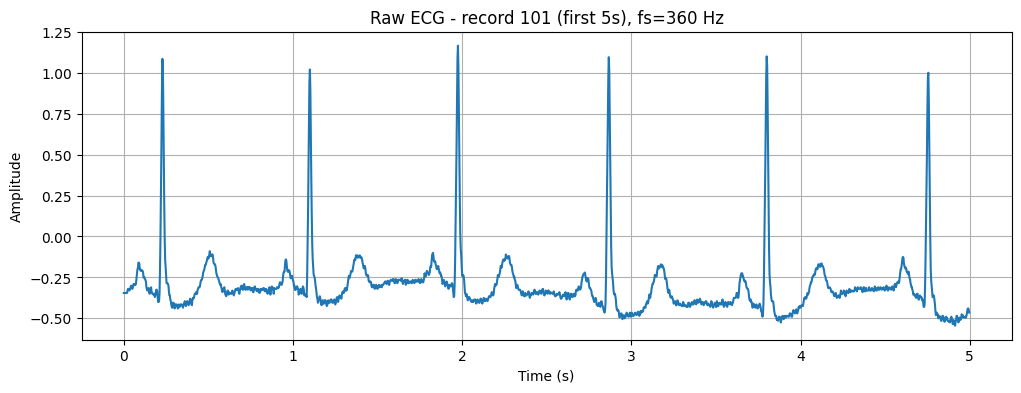

Sampling rate (fs): 360 Hz
Signal length: 650000 samples ~ 1805.5555555555557 seconds
Number of annotated R-peaks: 1874


In [ ]:
#vẽ ECG thô (ví dụ record 101, lead MLII)
rec_id = "101"      # đổi record nếu muốn
seconds = 5         # số giây muốn xem

ecg_raw = ecg_data[rec_id]["signal"]
fs = ecg_data[rec_id]["fs"]

n = min(int(seconds * fs), len(ecg_raw))
t = np.arange(n) / fs

plt.figure(figsize=(12,4))
plt.plot(t, ecg_raw[:n])
plt.title(f"Raw ECG - record {rec_id} (first {seconds}s), fs={fs} Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

print("Sampling rate (fs):", fs, "Hz")
print("Signal length:", len(ecg_raw), "samples ~", len(ecg_raw)/fs, "seconds")
print("Number of annotated R-peaks:", len(ecg_data[rec_id]["r_peaks"]))

Xác định phức hợp QRS và trích xuất đăc trưng từ tín hiệu ECG

In [ ]:
# 1) Truy cập dữ liệu WFDB (MIT-BIH)
def load_record(rec_id: str, lead_index: int = 0, pn_dir="mitdb", ann_ext="atr"):
    record = wfdb.rdrecord(rec_id, pn_dir=pn_dir)
    ann = wfdb.rdann(rec_id, ann_ext, pn_dir=pn_dir)

    ecg = record.p_signal[:, lead_index]
    fs = record.fs
    r_peaks = np.asarray(ann.sample, dtype=int)
    labels = np.asarray(ann.symbol)

    return ecg, fs, r_peaks, labels
def list_mitdb_records(prefix="1"):
    """List MIT-BIH records and optionally filter by prefix (e.g., '1' for 1xx)."""
    recs = wfdb.get_record_list("mitdb")
    if prefix is None:
        return recs
    return [r for r in recs if r.startswith(prefix)]

In [ ]:
# 2) Lọc / Tiền xử lý
def bandpass_filter(x, fs, low=0.5, high=40.0, order=4):
    nyq = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x)

def notch_filter(x, fs, freq=50.0, q=30.0):
    nyq = fs / 2
    w0 = freq / nyq
    b, a = iirnotch(freq/nyq, q)
    return filtfilt(b, a, x)

def zscore_norm(x):
    s = np.std(x) + 1e-12
    return (x - np.mean(x)) / s

In [ ]:
# 3) Phát hiện QRS 
def detect_r_peaks_pan_tompkins_like(x, fs):
    # bandpass nhấn mạnh QRS (~5–15Hz)
    xf = bandpass_filter(x, fs, low=5.0, high=15.0, order=2)

    # derivative + square
    dx = np.diff(xf, prepend=xf[0])
    sq = dx ** 2

    # moving window integrate ~150ms
    win = max(1, int(0.150 * fs))
    mwa = np.convolve(sq, np.ones(win) / win, mode="same")

    # find peaks
    min_dist = max(1, int(0.250 * fs))  # >=250ms
    thr = np.percentile(mwa, 95) * 0.3  # threshold tương đối
    peaks, _ = find_peaks(mwa, height=thr, distance=min_dist)

    # refine vị trí R: tìm max quanh peak trên x (±50ms)
    refined = []
    rad = max(1, int(0.050 * fs))
    for p in peaks:
        lo = max(0, p - rad)
        hi = min(len(x), p + rad + 1)
        refined.append(lo + int(np.argmax(x[lo:hi])))

    return np.unique(np.array(refined, dtype=int))

def get_r_peaks(ecg, fs, ann_r_peaks=None, mode="annotation"):
    if mode == "annotation":
        if ann_r_peaks is None:
            raise ValueError("Cần ann_r_peaks khi mode='annotation'")
        return np.asarray(ann_r_peaks, dtype=int)
    elif mode == "detect":
        return detect_r_peaks_pan_tompkins_like(ecg, fs)
    else:
        raise ValueError("mode phải là 'annotation' hoặc 'detect'")


In [ ]:
# 4) EDA plots
def plot_ecg_with_r(ecg, r_peaks, fs, seconds=5, title="ECG + R-peaks"):
    n = min(int(seconds * fs), len(ecg))
    t = np.arange(n) / fs
    rp = np.asarray(r_peaks, dtype=int)
    rp = rp[rp < n]


    plt.figure(figsize=(12, 3))
    plt.plot(t, ecg[:n], label="ECG")
    plt.scatter(rp / fs, ecg[rp], s=12, marker="x", label="R-peaks")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.grid(True)
    plt.legend()
    plt.show()

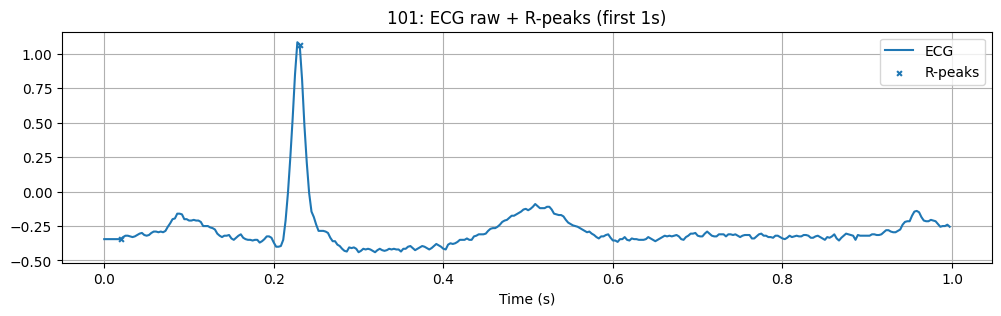

,r_idx,q_idx,s_idx,A_Q,A_R,A_S,QRS_width_ms
0,83,73,103,-0.400,1.065,-0.435,83.333333
1,396,389,413,-0.370,1.020,-0.405,66.666667
2,711,702,731,-0.370,1.165,-0.375,80.555556
3,1032,1023,1051,-0.465,1.095,-0.455,77.777778
4,1368,1359,1386,-0.490,1.100,-0.485,75.000000
5,1712,1702,1728,-0.430,1.000,-0.480,72.222222
6,2036,2023,2052,-0.545,1.065,-0.590,80.555556
7,2349,2341,2369,-0.450,1.375,-0.405,77.777778
8,2662,2654,2680,-0.365,1.305,-0.320,72.222222
9,2972,2963,2992,-0.445,1.220,-0.450,80.555556


count    1873.000000
mean       77.782227
std         5.506743
min         8.333333
25%        75.000000
50%        77.777778
75%        80.555556
max        94.444444
Name: QRS_width_ms, dtype: float64


In [ ]:
#5 trích xuất đặc trưng QRS đơn giản
def extract_qrs_features_simple(ecg, r_peaks, fs):
    # Q: min trong [R-40ms, R-5ms]
    # S: min trong [R+5ms, R+60ms]
    q_left  = int(0.040 * fs)
    q_right = int(0.005 * fs)
    s_left  = int(0.005 * fs)
    s_right = int(0.060 * fs)

    feats = []
    r_peaks = np.asarray(r_peaks, dtype=int)

    for r in r_peaks:
        if r - q_left < 0 or r + s_right >= len(ecg):
            continue

        q_lo = r - q_left
        q_hi = r - q_right
        q_idx = q_lo + int(np.argmin(ecg[q_lo:q_hi]))

        s_lo = r + s_left
        s_hi = r + s_right
        s_idx = s_lo + int(np.argmin(ecg[s_lo:s_hi]))

        feats.append({
            "r_idx": int(r),
            "q_idx": int(q_idx),
            "s_idx": int(s_idx),
            "A_Q": float(ecg[q_idx]),
            "A_R": float(ecg[r]),
            "A_S": float(ecg[s_idx]),
            "QRS_width_ms": float((s_idx - q_idx) * 1000.0 / fs),
        })

    return pd.DataFrame(feats)

# Demo cho 1 record
rec_id = "101"
seconds = 1

ecg_raw = ecg_data[rec_id]["signal"]
fs = ecg_data[rec_id]["fs"]
ann_r = ecg_data[rec_id]["r_peaks"]

# dùng annotation để identify QRS
r_peaks = get_r_peaks(ecg_raw, fs, ann_r_peaks=ann_r, mode="annotation")

# plot QRS
plot_ecg_with_r(ecg_raw, r_peaks, fs, seconds=seconds, title=f"{rec_id}: ECG raw + R-peaks (first {seconds}s)")

# other features (Q,S,QRS width)
df_qrs = extract_qrs_features_simple(ecg_raw, r_peaks, fs)
display(df_qrs.head(10))
print(df_qrs["QRS_width_ms"].describe())

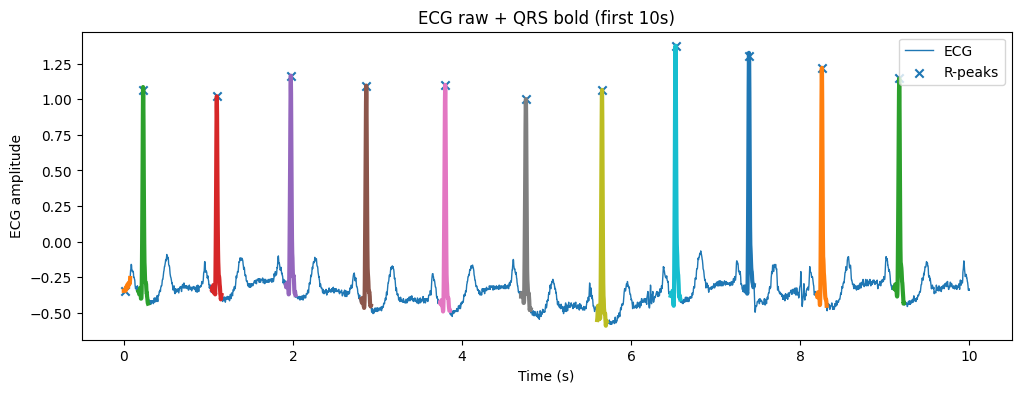

In [ ]:
# Vẽ ECG với QRS in đậm (cửa sổ cố định quanh R-peak)
def plot_ecg_qrs_bold_window(ecg, fs, r_peaks, seconds=10, qrs_window_ms=120):
    """
    In đậm QRS bằng cách lấy cửa sổ cố định quanh mỗi R-peak.
    qrs_window_ms: độ rộng vùng QRS (ms), ví dụ 100–140ms
    """
    n = int(seconds * fs)
    ecg_seg = ecg[:n]
    t = np.arange(n) / fs

    plt.figure(figsize=(12, 4))
    plt.plot(t, ecg_seg, linewidth=1, label="ECG")

    half = int((qrs_window_ms / 1000) * fs / 2)

    # In đậm các đoạn quanh R-peak
    for r in r_peaks:
        if r >= n:
            break
        s = max(0, r - half)
        e = min(n - 1, r + half)
        plt.plot(t[s:e], ecg_seg[s:e], linewidth=3)  # "in đậm"

    rp = np.array(r_peaks)
    rp = rp[rp < n]
    plt.scatter(rp / fs, ecg[rp], marker="x", label="R-peaks")

    plt.title(f"ECG raw + QRS bold (first {seconds}s)")
    plt.xlabel("Time (s)")
    plt.ylabel("ECG amplitude")
    plt.legend()
    plt.show()
rec_id = "101"
record = wfdb.rdrecord(rec_id, pn_dir="mitdb")
ecg = record.p_signal[:, 0]   # lead 0
fs = int(record.fs)
plot_ecg_qrs_bold_window(ecg, fs=360, r_peaks=r_peaks, seconds=10, qrs_window_ms=120)



Kiểm tra chất lượng tín hiệu ECG

In [ ]:
# 1) Filters / baseline estimation
def butter_filter(x, fs, low=None, high=None, order=4):
    """General Butterworth filter. Provide low/high for bandpass, only low for highpass, only high for lowpass."""
    nyq = fs / 2
    if low is None and high is None:
        return x
    if low is not None and high is not None:
        btype = "band"
        Wn = [low/nyq, high/nyq]
    elif low is not None:
        btype = "high"
        Wn = low/nyq
    else:
        btype = "low"
        Wn = high/nyq
    b, a = butter(order, Wn, btype=btype)
    return filtfilt(b, a, x)

def estimate_baseline(ecg, fs, cutoff=0.5):
    """Baseline wander estimate via low-pass filtering (<0.5 Hz)."""
    return butter_filter(ecg, fs, high=cutoff, order=2)

In [ ]:
# 2) Signal-level QC metrics
def psd_band_power(f, pxx, f1, f2):
    m = (f >= f1) & (f <= f2)
    if not np.any(m):
        return 0.0
    return float(np.trapz(pxx[m], f[m]))

def qc_signal_metrics(ecg, fs):
    """Compute baseline metrics + powerline ratios + HF noise ratio."""
    baseline = estimate_baseline(ecg, fs, cutoff=0.5)
    baseline_std = float(np.std(baseline))
    baseline_ptp = float(np.ptp(baseline))  # peak-to-peak

    # PSD
    f, pxx = welch(ecg, fs=fs, nperseg=min(len(ecg), 4096))

    p_0_40 = psd_band_power(f, pxx, 0.0, 40.0) + 1e-12
    p_49_51 = psd_band_power(f, pxx, 49.0, 51.0)
    p_59_61 = psd_band_power(f, pxx, 59.0, 61.0)
    p_20_40 = psd_band_power(f, pxx, 20.0, 40.0)

    powerline_50_ratio = float(p_49_51 / p_0_40)
    powerline_60_ratio = float(p_59_61 / p_0_40)
    hf_noise_ratio_20_40 = float(p_20_40 / p_0_40)

    # Raw amplitude stats
    amp_std = float(np.std(ecg))
    amp_min = float(np.min(ecg))
    amp_max = float(np.max(ecg))

    return {
        "baseline_std": baseline_std,
        "baseline_ptp": baseline_ptp,
        "powerline_50_ratio": powerline_50_ratio,
        "powerline_60_ratio": powerline_60_ratio,
        "hf_noise_ratio_20_40": hf_noise_ratio_20_40,
        "amp_std": amp_std,
        "amp_min": amp_min,
        "amp_max": amp_max,
        "baseline_series": baseline,
        "psd_f": f,
        "psd_pxx": pxx
    }


In [ ]:
# 3) Beat-level QC (RR sanity)
def compute_rr(r_peaks, fs):
    """RR intervals in seconds."""
    r_peaks = np.array(r_peaks, dtype=int)
    if len(r_peaks) < 2:
        return np.array([], dtype=float)
    return np.diff(r_peaks) / fs

def qc_rr_metrics(r_peaks, fs, rr_min=0.3, rr_max=2.5):
    rr = compute_rr(r_peaks, fs)
    if len(rr) == 0:
        return {"rr_min": None, "rr_max": None, "bad_rr_pct": None, "bad_rr_idx": [], "rr": rr}

    bad = (rr < rr_min) | (rr > rr_max)
    bad_idx = np.where(bad)[0].tolist()

    return {
        "rr_min": float(np.min(rr)),
        "rr_max": float(np.max(rr)),
        "bad_rr_pct": float(100.0 * np.mean(bad)),
        "bad_rr_idx": bad_idx,
        "rr": rr
    }

In [ ]:
# 4) Plotting (ECG+baseline, PSD, RR/HR hist)
def plot_ecg_with_baseline(ecg_raw, baseline, fs, seconds=10, title="ECG raw + baseline"):
    n = min(int(seconds * fs), len(ecg_raw))
    t = np.arange(n) / fs
    plt.figure(figsize=(12, 3))
    plt.plot(t, ecg_raw[:n], label="ECG raw")
    plt.plot(t, baseline[:n], label="Estimated baseline (<0.5Hz)")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_psd_welch_with_60_harmonics(
    x, fs,
    nperseg=None, noverlap=None, window="hann",
    fmax=360,                 # yêu cầu "<360" -> mình giới hạn tới min(fmax, fs/2)
    harmonic_base=60,         # bội số 60 Hz
    band_halfwidth=1.0,       # +/- 1 Hz quanh mỗi harmonic (tức band rộng 2 Hz)
    use_db=True,              # True: 10*log10(PSD)
    ax=None,
    title="PSD (Welch) with 60 Hz harmonics"
):
    x = np.asarray(x).astype(float)
    x = x - np.nanmean(x)

    # Welch params
    if nperseg is None:
        nperseg = min(len(x), int(fs * 4))  # mặc định 4s/cửa sổ
    if noverlap is None:
        noverlap = nperseg // 2

    f, pxx = welch(x, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, detrend="constant")

    # Giới hạn trục tần số: "<360" nhưng không vượt Nyquist
    fmax_eff = min(float(fmax), fs / 2.0)
    mask = (f >= 0) & (f <= fmax_eff)
    f_plot = f[mask]
    p_plot = pxx[mask]

    # Chuẩn bị trục
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    if use_db:
        y = 10 * np.log10(p_plot + 1e-20)
        ax.plot(f_plot, y, linewidth=1.2)
        ax.set_ylabel("PSD (dB/Hz)")
    else:
        ax.semilogy(f_plot, p_plot, linewidth=1.2)
        ax.set_ylabel("PSD (V²/Hz)")

    ax.set_xlabel("Frequency (Hz)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # Tô dải quanh các bội số của 60 Hz
    # (chỉ các harmonic <= fmax_eff)
    harmonics = np.arange(harmonic_base, fmax_eff + 1e-9, harmonic_base)
    for h in harmonics:
        left = max(0.0, h - band_halfwidth)
        right = min(fmax_eff, h + band_halfwidth)
        ax.axvspan(left, right, alpha=0.15)
        ax.axvline(h, linestyle="--", linewidth=1.0, alpha=0.6)

    ax.set_xlim(0, fmax_eff)
    return ax

def plot_rr_hist(rr, title="RR distribution"):
    plt.figure(figsize=(6, 4))
    plt.hist(rr, bins=50)
    plt.title(title)
    plt.xlabel("RR (s)")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

def plot_hr_hist(rr, title="HR distribution"):
    if len(rr) == 0:
        print("No RR intervals to plot HR.")
        return
    hr = 60.0 / (rr + 1e-12)
    plt.figure(figsize=(6, 4))
    plt.hist(hr, bins=50)
    plt.title(title)
    plt.xlabel("HR (bpm)")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

/var/folders/k5/w77q5v455sqchk9vfs41w8_h0000gn/T/ipykernel_2995/382298698.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(pxx[m], f[m]))


,record_id,fs_hz,duration_s,num_beats,baseline_std,baseline_ptp,powerline_50_ratio,powerline_60_ratio,hf_noise_ratio_20_40,amp_std,amp_min,amp_max,rr_min,rr_max,bad_rr_pct
0,101,360,1805.555556,1874,0.117683,3.093681,0.000433,0.000763,0.083224,0.261156,-3.175,2.42,0.066667,1.275,0.427122


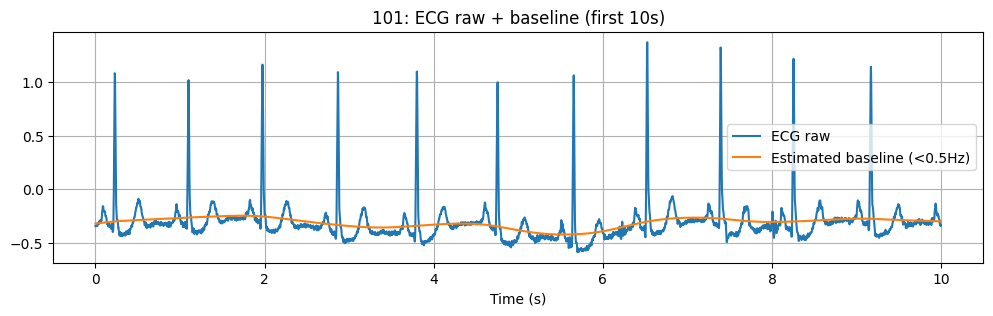

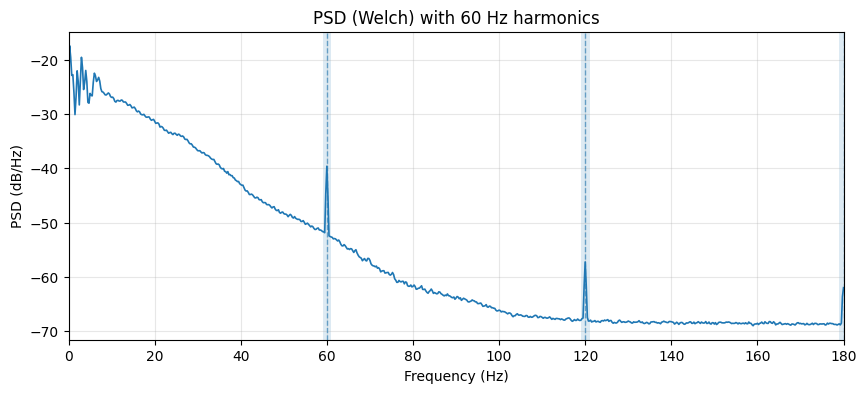

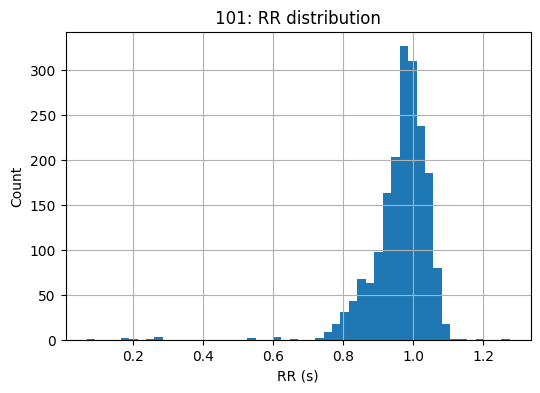

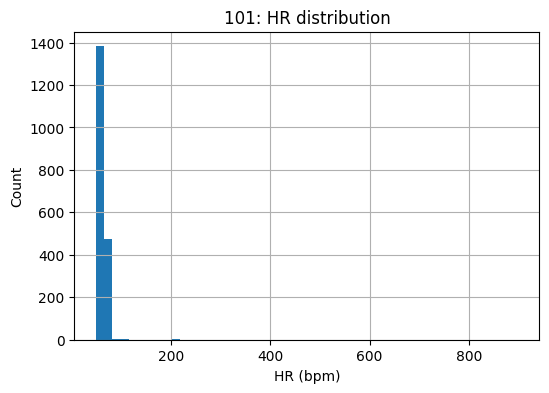

In [ ]:
# Demo cho 1 record
rec_id = "101"
seconds_plot = 10

ecg_raw = ecg_data[rec_id]["signal"]
fs = ecg_data[rec_id]["fs"]
r_peaks = np.asarray(ecg_data[rec_id]["r_peaks"], dtype=int)

sig_qc = qc_signal_metrics(ecg_raw, fs)
rr_qc  = qc_rr_metrics(r_peaks, fs)

qc_output = {
    "record_id": rec_id,
    "fs_hz": fs,
    "duration_s": len(ecg_raw)/fs,
    "num_beats": len(r_peaks),
    "baseline_std": sig_qc["baseline_std"],
    "baseline_ptp": sig_qc["baseline_ptp"],
    "powerline_50_ratio": sig_qc["powerline_50_ratio"],
    "powerline_60_ratio": sig_qc["powerline_60_ratio"],
    "hf_noise_ratio_20_40": sig_qc["hf_noise_ratio_20_40"],
    "amp_std": sig_qc["amp_std"],
    "amp_min": sig_qc["amp_min"],
    "amp_max": sig_qc["amp_max"],
    "rr_min": rr_qc["rr_min"],
    "rr_max": rr_qc["rr_max"],
    "bad_rr_pct": rr_qc["bad_rr_pct"],
}
display(pd.DataFrame([qc_output]))

plot_ecg_with_baseline(ecg_raw, sig_qc["baseline_series"], fs, seconds=seconds_plot,
                       title=f"{rec_id}: ECG raw + baseline (first {seconds_plot}s)")
ax = plot_psd_welch_with_60_harmonics(ecg_raw, fs=360, band_halfwidth=1.0, fmax=360)
plot_rr_hist(rr_qc["rr"], title=f"{rec_id}: RR distribution")
plot_hr_hist(rr_qc["rr"], title=f"{rec_id}: HR distribution")


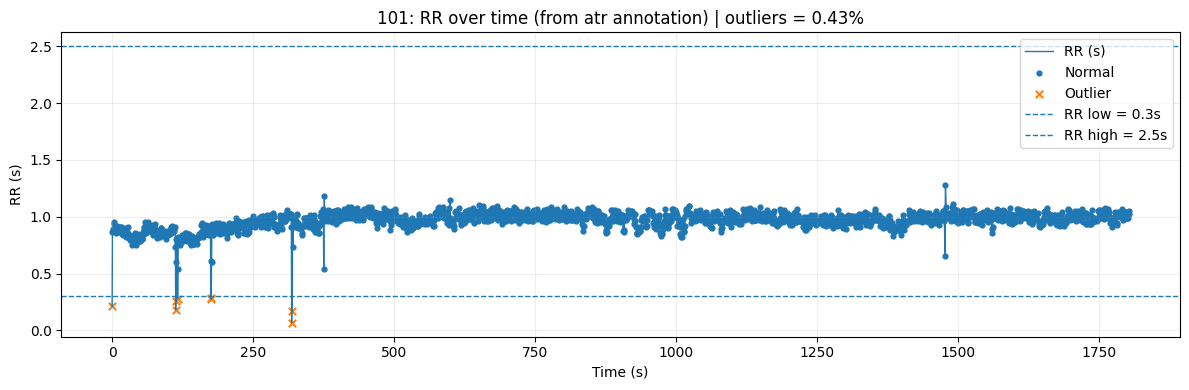

First 20 outlier RR indices: [  0 132 134 138 210 212 366 368]


In [ ]:
# biểu đồ Outlier RR
#  Compute RR series
r_times = r_peaks / fs                 # time of each R-peak (s)
rr = np.diff(r_times)                  # RR intervals (s)
t_rr = (r_times[:-1] + r_times[1:]) / 2  # timestamp for each RR (midpoint)

#  Outlier rule
rr_low, rr_high = 0.3, 2.5
out_mask = (rr < rr_low) | (rr > rr_high)
bad_rr_pct = 100 * out_mask.mean() if len(rr) else 0

# chỉ vẽ 5 phút đầu
max_time = None  # ví dụ 300 để vẽ 5 phút đầu
if max_time is not None:
    keep = t_rr <= max_time
    t_rr, rr, out_mask = t_rr[keep], rr[keep], out_mask[keep]

# Plot RR over time + highlight outliers
plt.figure(figsize=(12, 4))
plt.plot(t_rr, rr, linewidth=1, label="RR (s)")
plt.scatter(t_rr[~out_mask], rr[~out_mask], s=12, label="Normal")
plt.scatter(t_rr[out_mask], rr[out_mask], s=28, marker="x", label="Outlier")

plt.axhline(rr_low, linestyle="--", linewidth=1, label=f"RR low = {rr_low}s")
plt.axhline(rr_high, linestyle="--", linewidth=1, label=f"RR high = {rr_high}s")

plt.title(f"{rec_id}: RR over time (from atr annotation) | outliers = {bad_rr_pct:.2f}%")
plt.xlabel("Time (s)")
plt.ylabel("RR (s)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

#  in ra index các RR outlier để bạn trace ngược
out_idx = np.where(out_mask)[0]
print("First 20 outlier RR indices:", out_idx[:20])


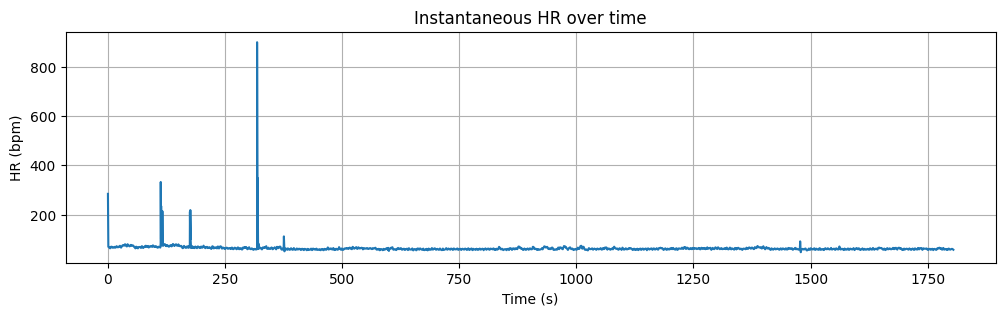

In [ ]:
# biểu đồ chuỗi nhịp tim record 101
# RR & HR from R-peaks
rr = np.diff(r_peaks) / fs
hr = 60.0 / (rr + 1e-12)
t_beats = r_peaks[1:] / fs

# Plot HR time series
plt.figure(figsize=(12,3))
plt.plot(t_beats, hr)
plt.title("Instantaneous HR over time")
plt.xlabel("Time (s)")
plt.ylabel("HR (bpm)")
plt.grid(True)
plt.show()



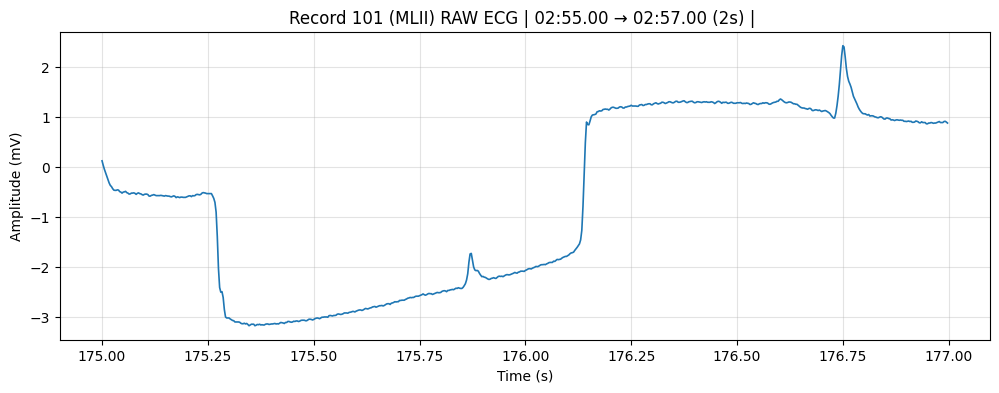

In [ ]:
# visualize lỗi biên độ ECG thô trong record 101
rec_id = "101"
record = wfdb.rdrecord(rec_id, pn_dir="mitdb")
start_time_s = 2*60 + 55.00   # 175.00 s
dur_s = 2.0

start_idx = int(start_time_s * fs)   # = 63000 nếu fs=360
end_idx = start_idx + int(dur_s * fs)

t = np.arange(start_idx, end_idx) / fs
seg = ecg[start_idx:end_idx]

plt.figure(figsize=(12, 4))
plt.plot(t, seg, linewidth=1.2)
plt.title(f"Record 101 (MLII) RAW ECG | 02:55.00 → 02:57.00 (2s) | ")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True, alpha=0.35)
plt.show()

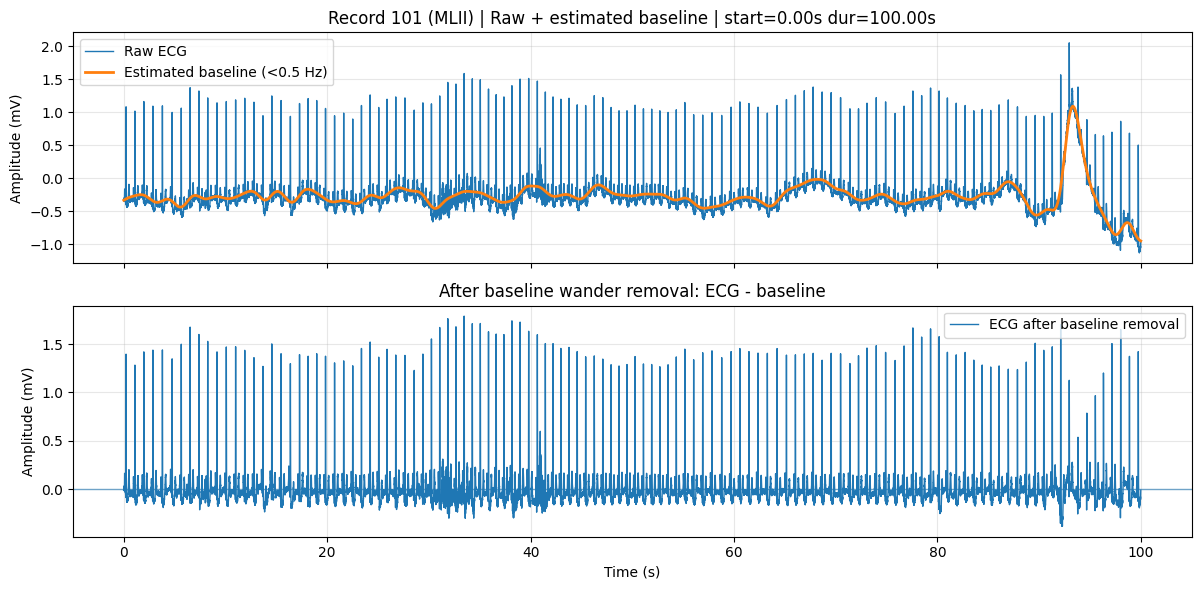

In [ ]:
#visualize trôi nền và loại bỏ trôi nền bằng lọc thông thấp
def lowpass_baseline(x, fs, cutoff=0.5, order=4):
    """Ướine wc lượng baselander bằng low-pass Butterworth + filtfilt (zero-phase)."""
    x = np.asarray(x, dtype=float)
    nyq = fs / 2.0
    wn = cutoff / nyq
    b, a = butter(order, wn, btype="low")
    return filtfilt(b, a, x)

def remove_baseline_wander(ecg, fs, cutoff=0.5, order=4):
    baseline = lowpass_baseline(ecg, fs, cutoff=cutoff, order=order)
    ecg_detrend = ecg - baseline
    return baseline, ecg_detrend

def plot_baseline_removal(ecg, baseline, ecg_detrend, fs, start_s=0.0, dur_s=10.0,
                          title_prefix="Record 101 (MLII)"):
    i0 = int(start_s * fs)
    i1 = min(len(ecg), i0 + int(dur_s * fs))
    t = np.arange(i0, i1) / fs

    fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # Plot 1: Raw + baseline
    axs[0].plot(t, ecg[i0:i1], linewidth=1.0, label="Raw ECG")
    axs[0].plot(t, baseline[i0:i1], linewidth=2.0, label="Estimated baseline (<0.5 Hz)")
    axs[0].set_title(f"{title_prefix} | Raw + estimated baseline | start={start_s:.2f}s dur={dur_s:.2f}s")
    axs[0].set_ylabel("Amplitude (mV)")
    axs[0].grid(True, alpha=0.3)
    axs[0].legend()

    # Plot 2: Detrended
    axs[1].plot(t, ecg_detrend[i0:i1], linewidth=1.0, label="ECG after baseline removal")
    axs[1].axhline(0, linewidth=1.0, alpha=0.6)
    axs[1].set_title("After baseline wander removal: ECG - baseline")
    axs[1].set_xlabel("Time (s)")
    axs[1].set_ylabel("Amplitude (mV)")
    axs[1].grid(True, alpha=0.3)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

# ====== Load record 101 ======
record = wfdb.rdrecord("101", pn_dir="mitdb")
fs = int(record.fs)
ecg = record.p_signal[:, 0]  # MLII

# ====== Remove baseline wander ======
baseline, ecg_detrend = remove_baseline_wander(ecg, fs, cutoff=0.5, order=4)

# ====== Visualize (chọn đoạn để nhìn rõ trôi nền) ======
plot_baseline_removal(ecg, baseline, ecg_detrend, fs, start_s=0, dur_s=100)


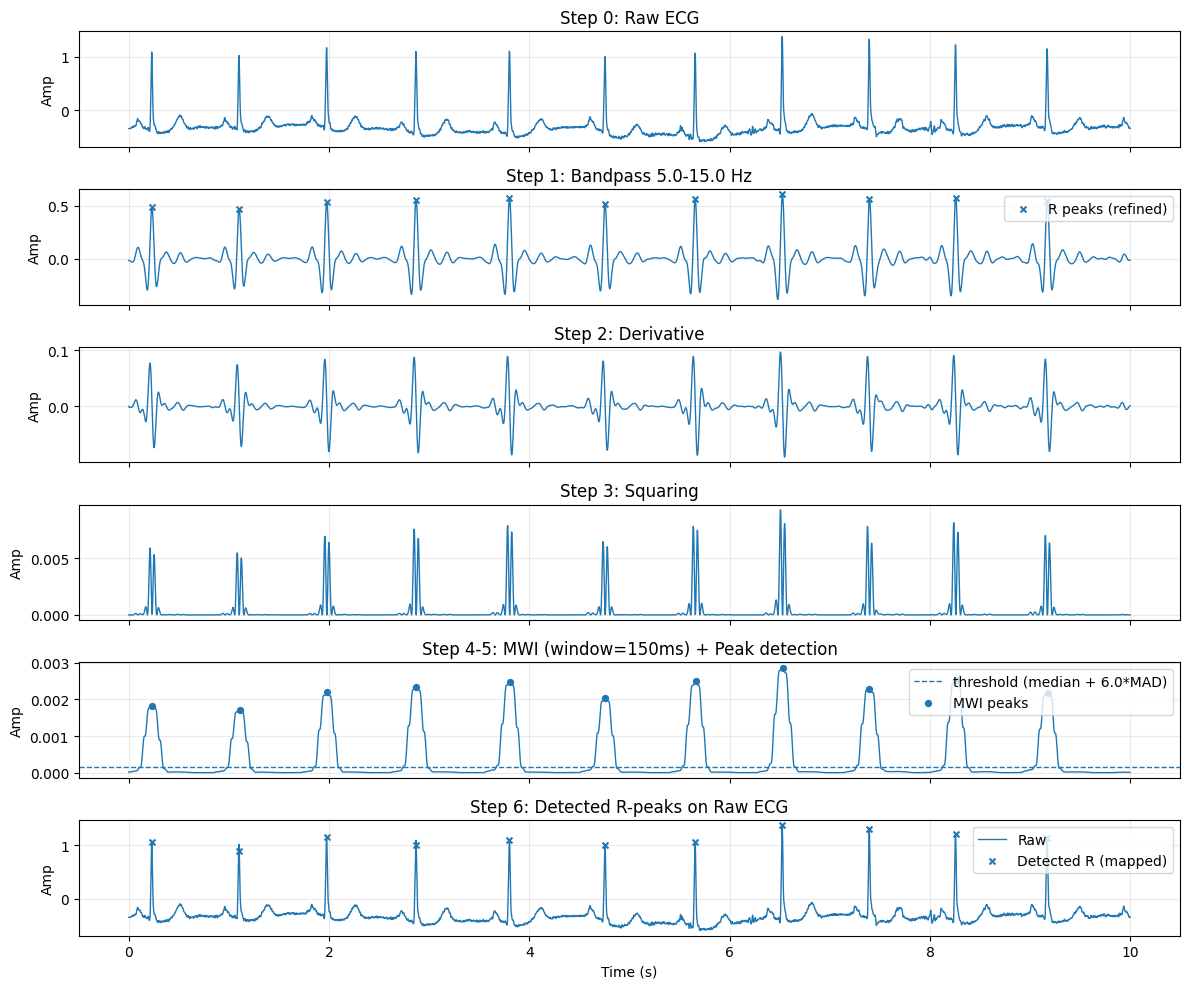

Detected R-peaks (sample indices): [  83  397  711 1033 1368 1712 2036 2349 2662 2972] ...
Detected R-peaks (seconds): [0.23055556 1.10277778 1.975      2.86944444 3.8        4.75555556
 5.65555556 6.525      7.39444444 8.25555556]


In [ ]:
# QRS detection steps with visualization
def bandpass(x, fs, low=5.0, high=15.0, order=3):
    nyq = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x)

def moving_average(x, N):
    N = max(1, int(N))
    return np.convolve(x, np.ones(N)/N, mode="same")

def robust_threshold(x, k=6.0):
    # threshold = median + k*MAD (robust, ít bị spike kéo)
    x = np.asarray(x, float)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-12
    return med + k * mad

def qrs_steps_and_plot(ecg, fs, start_s=0.0, dur_s=10.0,
                       bp_low=5.0, bp_high=15.0,
                       mwi_ms=150,
                       thr_k=6.0,
                       refractory_ms=200):
    ecg = np.asarray(ecg, float)

    i0 = int(start_s * fs)
    i1 = min(len(ecg), i0 + int(dur_s * fs))
    x = ecg[i0:i1]
    t = np.arange(i0, i1) / fs

    # 1) Bandpass (QRS band)
    xf = bandpass(x, fs, low=bp_low, high=bp_high, order=3)

    # 2) Derivative
    d = np.diff(xf, prepend=xf[0])

    # 3) Squaring
    s = d**2

    # 4) Moving window integration
    N = int((mwi_ms/1000.0) * fs)
    m = moving_average(s, N)

    # 5) Detect peaks on MWI
    thr = robust_threshold(m, k=thr_k)
    refractory = int((refractory_ms/1000.0) * fs)
    peaks_m, props = find_peaks(m, height=thr, distance=refractory)

    # 6) Refine R-peaks: search max in xf around each MWI peak
    search = int(0.15 * fs)  # ±150ms
    r_peaks = []
    for p in peaks_m:
        a = max(0, p - search)
        b = min(len(xf), p + search + 1)
        r = a + np.argmax(xf[a:b])
        r_peaks.append(r)
    r_peaks = np.array(r_peaks, dtype=int)

    # ===== Plot steps =====
    fig, axs = plt.subplots(6, 1, figsize=(12, 10), sharex=True)

    axs[0].plot(t, x, lw=1.0)
    axs[0].set_title("Step 0: Raw ECG")

    axs[1].plot(t, xf, lw=1.0)
    axs[1].scatter(t[r_peaks], xf[r_peaks], s=18, marker="x", label="R peaks (refined)")
    axs[1].legend(loc="upper right")
    axs[1].set_title(f"Step 1: Bandpass {bp_low}-{bp_high} Hz")

    axs[2].plot(t, d, lw=1.0)
    axs[2].set_title("Step 2: Derivative")

    axs[3].plot(t, s, lw=1.0)
    axs[3].set_title("Step 3: Squaring")

    axs[4].plot(t, m, lw=1.0)
    axs[4].axhline(thr, ls="--", lw=1.0, label=f"threshold (median + {thr_k}*MAD)")
    axs[4].scatter(t[peaks_m], m[peaks_m], s=18, marker="o", label="MWI peaks")
    axs[4].legend(loc="upper right")
    axs[4].set_title(f"Step 4-5: MWI (window={mwi_ms}ms) + Peak detection")

    # Overlay: raw vs detected R for sanity
    axs[5].plot(t, x, lw=1.0, label="Raw")
    axs[5].scatter(t[r_peaks], x[r_peaks], s=18, marker="x", label="Detected R (mapped)")
    axs[5].legend(loc="upper right")
    axs[5].set_title("Step 6: Detected R-peaks on Raw ECG")

    for ax in axs:
        ax.grid(True, alpha=0.25)
        ax.set_ylabel("Amp")
    axs[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

    # trả về chỉ số mẫu theo toàn record (cộng offset i0)
    return (r_peaks + i0), (peaks_m + i0)

# ===== Load record 101 =====
record = wfdb.rdrecord("101", pn_dir="mitdb")
fs = int(record.fs)
ecg = record.p_signal[:, 0]  # MLII

# Visualize 10s để nhìn rõ từng bước
r_peaks, mwi_peaks = qrs_steps_and_plot(ecg, fs, start_s=0.0, dur_s=10.0)

print("Detected R-peaks (sample indices):", r_peaks[:10], "...")
print("Detected R-peaks (seconds):", (r_peaks[:10]/fs))


Dữ liệu chuỗi thời gian nhịp tim (Cách A):
   Time_Seconds  RR_Interval_Sec  Heart_Rate_BPM
0      0.213889         0.163889      366.101695
1      1.027778         0.813889       73.720137
2      1.838889         0.811111       73.972603
3      2.627778         0.788889       76.056338
4      3.419444         0.791667       75.789474


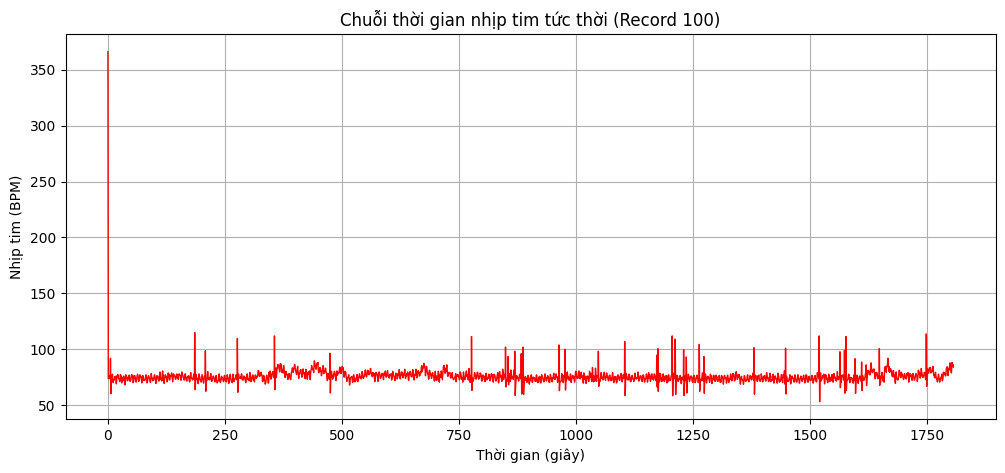

In [ ]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

record_name = '100'
LIMIT_MINUTES = 5
record = wfdb.rdrecord(record_name, pn_dir='mitdb')
annotation = wfdb.rdann(record_name, 'atr', pn_dir='mitdb')

# 2. Lấy vị trí các đỉnh R (tính theo đơn vị mẫu - samples)
# Chú thích 'atr' chứa vị trí các đỉnh R do chuyên gia đánh dấu
r_peaks = annotation.sample 

# 3. Lấy tần số lấy mẫu (fs) - MIT-BIH luôn là 360Hz
fs = record.fs 

# 4. Tính khoảng cách giữa các đỉnh R liên tiếp (RR intervals)
# Đơn vị: samples
rr_samples = np.diff(r_peaks)

# 5. Đổi khoảng cách RR sang đơn vị giây
rr_seconds = rr_samples / fs

# 6. Tính Nhịp tim tức thời (Heart Rate - BPM)
# Công thức: HR = 60 / RR(giây)
heart_rate = 60 / rr_seconds

# 7. Tạo mảng thời gian tương ứng (tính bằng giây) cho mỗi giá trị HR
# Chúng ta lấy thời điểm của đỉnh R thứ hai trong mỗi cặp làm mốc thời gian
time_stamps = r_peaks[1:] / fs

# 8. Tổng hợp thành DataFrame để dễ dàng phân tích/làm chuỗi thời gian
df_hr = pd.DataFrame({
    'Time_Seconds': time_stamps,
    'RR_Interval_Sec': rr_seconds,
    'Heart_Rate_BPM': heart_rate
})

# Hiển thị 5 dòng đầu tiên
print("Dữ liệu chuỗi thời gian nhịp tim (Cách A):")
print(df_hr.head())

# 9. Vẽ biểu đồ chuỗi thời gian nhịp tim
plt.figure(figsize=(12, 5))
plt.plot(df_hr['Time_Seconds'], df_hr['Heart_Rate_BPM'], color='red', linewidth=1)
plt.title(f'Chuỗi thời gian nhịp tim tức thời (Record {record_name})')
plt.xlabel('Thời gian (giây)')
plt.ylabel('Nhịp tim (BPM)')
plt.grid(True)
plt.show()